# Rainfall Analysis in Rio de Janeiro: From Thiessen Polygons to Event Characterization

This notebook presents a comprehensive workflow for analyzing pluviometric data in Rio de Janeiro. It starts by estimating areal average rainfall using static Thiessen polygons and then proceeds to identify and characterize significant rainfall events using various methodologies. Finally, it provides detailed visualizations of top rainfall events.

**Overall Methodology:**

1.  **Part 1: Static Thiessen Polygons & Areal Rainfall Estimation**
    *   Setup: Import libraries, define paths and constants.
    *   Load & Process Data: Pluviometric records, station locations, city boundary, and flood occurrence data.
    *   CRS Transformation: Convert spatial data to a projected CRS.
    *   Generate Static Thiessen Polygons: Create Voronoi cells and clip them to the city boundary.
    *   Calculate Polygon Weights: Determine the influence area of each rain gauge.
    *   Calculate Time-Series Areal Average Rainfall: Compute 15-minute areal rainfall.
    *   Visualization & Results: Plot Thiessen polygons and the areal rainfall time series.
    *   Save Outputs: Store polygons and areal rainfall data.
2.  **Part 2: Advanced Rainfall Event Analysis**
    *   Data Regularization: Standardize areal rainfall to 15-minute intervals.
    *   Analysis 1: Daily Rainfall Aggregation.
    *   Analysis 2: Continuous Rainfall Period Identification (Rain Events).
    *   Analysis 3: Peak Over Threshold (POT) Event Analysis.
    *   Save Event Analysis Outputs.
3.  **Part 3: Evaluation and Comparison of Rainfall Event Identification Methods**
    *   Recap of Identified Events from all three methods.
    *   Detailed Evaluation of Daily, Continuous, and POT methods (distributions, strengths, weaknesses).
    *   Overlap Analysis: Compare events identified by different methods.
    *   Temporal Coincidence Analysis: Visualize if top events align in time.
    *   Discussion on Method Selection for various applications.
    *   Enhanced Conclusions and Future Directions.
4.  **Part 4: Focused Visualization of Top Rain Events with Hourly Maps**
    *   Selection of the "best" method (Continuous Rain Events) for defining top events to visualize.
    *   Generation of 3-hourly rainfall maps for the top 10 selected rain events, overlaid with flood occurrences.

---

## Part 1: Static Thiessen Polygons & Areal Rainfall Estimation

This part implements the Thiessen Polygon method to estimate areal average rainfall for Rio de Janeiro city using 15-minute pluviometric data. This approach uses **static Thiessen polygons**, meaning the polygons are generated once based on station locations and then applied across all timestamps.

### 1.1. Setup and Imports

In [1]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np
from scipy.spatial import Voronoi
from shapely.geometry import Polygon, Point, MultiPolygon
from shapely.ops import unary_union
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches # For custom legends
import seaborn as sns
import matplotlib.dates as mdates
import warnings

# Plotting style for nicer academic-ready charts
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis") # A good colormap for sequential data

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

# Cartopy imports for Part 4, placed here for consolidated imports
try:
    import cartopy.crs as ccrs
    import cartopy.io.img_tiles as cimgt
    from matplotlib.colors import ListedColormap, BoundaryNorm
    import matplotlib.patheffects as PathEffects
    import matplotlib.gridspec as gridspec
except ImportError:
    print("Cartopy or related libraries not found. Map visualizations in Part 4 may fail. Install with: pip install cartopy")
    ccrs = None

# Calmap for calendar heatmaps (Part 2)
try:
    import calmap
except ImportError:
    print("calmap library not found. Calendar heatmap in Part 2 will be skipped. Install with: pip install calmap")
    calmap = None

# Try to set working directory to the notebook's directory robustly
try:
    # This works in JupyterLab, but not always in VSCode
    notebook_path = os.path.abspath("work/projects/meteorologia/nbs/data-analysis")
    if os.path.basename(notebook_path) == "site-packages":
        # Fallback: set to a known path (user should adjust as needed)
        notebook_path = "/home/luisresende/work/projects/meteorologia/nbs/data-analysis"
    os.chdir(notebook_path)
    print(f"Working directory set to: {os.getcwd()}")
except Exception as e:
    print(f"Could not set working directory automatically: {e}")

Working directory set to: /home/luisresende/work/projects/meteorologia/nbs/data-analysis


### 1.2. Define Paths and Constants

In [2]:
# --- Input Data Paths ---
INPUT_DATA_DIRECTORY_BASE = '../../../../data' # General base for data
METEO_CLEAN_PATH = f'{INPUT_DATA_DIRECTORY_BASE}/meteorologia/clean'
RAW_DATA_PATH = f'{INPUT_DATA_DIRECTORY_BASE}/raw' # Example for pops.csv if it's there
LOCAL_RAW_DATA_PATH = f'../../data/raw' # Example for pops.csv if it's there


ALERTARIO_CSV_PATH = f'{METEO_CLEAN_PATH}/clima_pluviometro/taxa_precipitacao_alertario_manual.csv'
STATIONS_CSV_PATH = f'{METEO_CLEAN_PATH}/clima_pluviometro/estacoes_alertario.csv'
OCORRENCIAS_CSV_PATH = f'{METEO_CLEAN_PATH}/adm_cor_comando/ocorrencias.csv'
POPS_CSV_PATH = f'{LOCAL_RAW_DATA_PATH}/adm_cor_comando/pops.csv' # Adjusted path
CITY_BOUNDARY_FILE_PATH = f'{METEO_CLEAN_PATH}/limites_geograficos_rj/limite_municipio_rio_de_janeiro.gpkg'

# --- Output Data Paths ---
OUTPUT_DATA_DIRECTORY = f'{INPUT_DATA_DIRECTORY_BASE}/meteorologia/processed/thiessen_analysis'
THIESSEN_POLYGONS_FILENAME = 'thiessen_polygons_rio.gpkg'
AREAL_RAINFALL_FILENAME = 'areal_rainfall_15min_rio.csv'
DAILY_RAINFALL_FILENAME = 'daily_areal_rainfall_rio.csv'
RAIN_EVENTS_FILENAME = 'rain_events_rio.csv'
POT_EVENTS_FILENAME = 'pot_events_rio.csv'


# --- CRS Definitions ---
CRS_GEOGRAPHIC = "EPSG:4326"  # WGS84 for input lat/lon
CRS_PROJECTED = "EPSG:31983"  # SIRGAS 2000 / UTM zone 23S (suitable for Rio de Janeiro for area calculations)

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DATA_DIRECTORY, exist_ok=True)

### 1.3. Load and Process Data

This section loads all necessary input datasets: precipitation records, station locations, city boundaries, and flood occurrence data. Each dataset undergoes initial processing and cleaning.

#### 1.3.1. Load Raw Data

In [3]:
try:
    alertario_raw = pd.read_csv(ALERTARIO_CSV_PATH)
    stations_raw = pd.read_csv(STATIONS_CSV_PATH)
    ocorrencias_raw = pd.read_csv(OCORRENCIAS_CSV_PATH)
    pops_raw = pd.read_csv(POPS_CSV_PATH, index_col=0)
    city_boundary_gdf_raw = gpd.read_file(CITY_BOUNDARY_FILE_PATH)
except FileNotFoundError as e:
    print(f"Error loading data: {e}. Please ensure all input files are correctly placed.")
    raise

print("Raw data loaded successfully.")

Raw data loaded successfully.


#### 1.3.2. Process Precipitation Data (`alertario`)

In [4]:
alertario = alertario_raw # .copy() # (Copy method commented for memory-efficiency)

# Convert datetime data type fields
alertario['horario'] = pd.to_timedelta(alertario['horario'])
alertario['data_particao'] = pd.to_datetime(alertario['data_particao'])
alertario['timestamp'] = pd.to_datetime(alertario['timestamp'])

# Map station name and coordinates from stations_raw
station_name_map = stations_raw.set_index('id_estacao')['estacao']
station_latitude_map = stations_raw.set_index('id_estacao')['latitude']
station_longitude_map = stations_raw.set_index('id_estacao')['longitude']

alertario['estacao'] = alertario['id_estacao'].map(station_name_map)
alertario['latitude'] = alertario['id_estacao'].map(station_latitude_map)
alertario['longitude'] = alertario['id_estacao'].map(station_longitude_map)

# Reorder columns
alertario = alertario[[
    'primary_key', 'id_estacao', 'estacao', 'latitude', 'longitude',
    'horario', 'data_particao', 'timestamp', 'acumulado_chuva_15_min',
    'acumulado_chuva_1_h', 'acumulado_chuva_4_h',
    'acumulado_chuva_24_h', 'acumulado_chuva_96_h'
]]

# Ensure rainfall data is numeric and handle NaNs
alertario['acumulado_chuva_15_min'] = pd.to_numeric(alertario['acumulado_chuva_15_min'], errors='coerce')
alertario['acumulado_chuva_15_min'] = alertario['acumulado_chuva_15_min'].fillna(0) # Assume missing means no rain for this interval

print("\nProcessed 'alertario' DataFrame (Info and Describe):")
alertario.info()
# display(alertario.describe())


Processed 'alertario' DataFrame (Info and Describe):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30670823 entries, 0 to 30670822
Data columns (total 13 columns):
 #   Column                  Dtype          
---  ------                  -----          
 0   primary_key             object         
 1   id_estacao              int64          
 2   estacao                 object         
 3   latitude                float64        
 4   longitude               float64        
 5   horario                 timedelta64[ns]
 6   data_particao           datetime64[ns] 
 7   timestamp               datetime64[ns] 
 8   acumulado_chuva_15_min  float64        
 9   acumulado_chuva_1_h     float64        
 10  acumulado_chuva_4_h     float64        
 11  acumulado_chuva_24_h    float64        
 12  acumulado_chuva_96_h    float64        
dtypes: datetime64[ns](2), float64(7), int64(1), object(2), timedelta64[ns](1)
memory usage: 3.0+ GB


#### 1.3.3. Process Station Locations (`stations`)

#### 1.3.4. Process City Boundary


City Boundary GeoDataFrame (first 5 rows):


,city_identifier,id_bairro,nome,id_area_planejamento,id_regiao_planejamento,nome_regiao_planejamento,id_regiao_administrativa,nome_regiao_administrativa,area,perimetro,geometry_wkt,geometry
0,Rio de Janeiro,1,Saúde,1,1.1,Centro,1,Portuaria,363817.622559,2646.220568,POLYGON ((-43.181151633502964 -22.895430284304...,"MULTIPOLYGON (((-43.56863 -23.08168, -43.56871..."


CRS of city boundary: EPSG:4326


NameError: name 'stations_gdf' is not defined

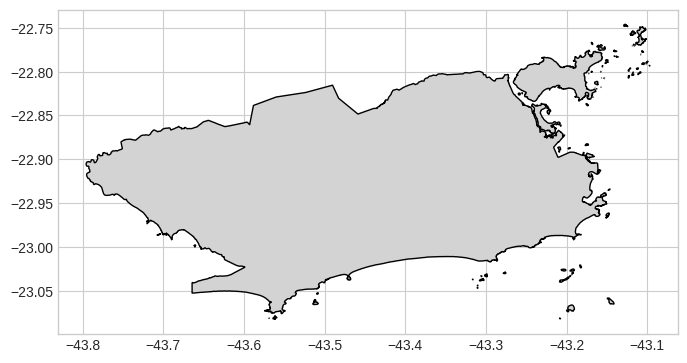

In [5]:
city_boundary_gdf = city_boundary_gdf_raw.copy()
print("\nCity Boundary GeoDataFrame (first 5 rows):")
display(city_boundary_gdf.head())
print(f"CRS of city boundary: {city_boundary_gdf.crs}")

# Plot to verify
fig, ax = plt.subplots(1,1, figsize=(8,8))
city_boundary_gdf.plot(ax=ax, facecolor='lightgray', edgecolor='black')
# Plot only stations_gdf which is already filtered and in geographic CRS for this plot
gpd.GeoDataFrame(
    stations_gdf[stations_gdf['id_estacao'].isin(stations_gdf['id_estacao'])], # Use raw for original lat/lon
    geometry=gpd.points_from_xy(stations_gdf[stations_gdf['id_estacao'].isin(stations_gdf['id_estacao'])].longitude, 
                                stations_gdf[stations_gdf['id_estacao'].isin(stations_gdf['id_estacao'])].latitude),
    crs=CRS_GEOGRAPHIC
).plot(ax=ax, color='red', markersize=50, label='Active Stations')
plt.title("City Boundary and Active Station Locations (Geographic CRS)")
plt.legend()
plt.show()

#### 1.3.5. Process Flood Occurrences (`ocorrencias`)

In [ ]:
ocorrencias = ocorrencias_raw.copy()

# Convert datetime fields
ocorrencias['data_inicio'] = pd.to_datetime(ocorrencias['data_inicio'], errors='coerce')
ocorrencias['data_fim'] = pd.to_datetime(ocorrencias['data_fim'], errors='coerce')

# Map event type using pops_raw
ocorrencias['tipo'] = ocorrencias['id_pop'].map(pops_raw.set_index('id')['titulo'])

# Filter occurrences by relevant types
relevant_types = ["Bolsão d'água em via", 'Alagamentos e enchentes']
ocorrencias = ocorrencias[ocorrencias['tipo'].isin(relevant_types)]
ocorrencias = ocorrencias.dropna(subset=['latitude', 'longitude', 'data_inicio'])


print(f"\nProcessed Ocorrencias DataFrame (filtered for types: {relevant_types}):")
display(ocorrencias.head())

# Convert to GeoDataFrame
ocorrencias_gdf = gpd.GeoDataFrame(
    ocorrencias,
    geometry=gpd.points_from_xy(ocorrencias.longitude, ocorrencias.latitude),
    crs=CRS_GEOGRAPHIC
)
print(f"Number of relevant flood occurrences: {len(ocorrencias_gdf)}")


Processed Ocorrencias DataFrame (filtered for types: ["Bolsão d'água em via", 'Alagamentos e enchentes']):


,id_pop,id_evento,bairro,data_inicio,data_fim,prazo,descricao,gravidade,latitude,longitude,status,tipo,data_particao,prazo_num
622,5.0,66955,Caju,2021-10-15 22:11:46+00:00,2021-10-15 22:16:00+00:00,Curto,"Av. rio de janeiro, 675 - caju",Baixo,-22.891448,-43.214630,Fechado,Bolsão d'água em via,2021-10-15,NaN
623,5.0,67278,Lagoa,2021-10-24 16:34:17+00:00,2021-10-24 19:52:44+00:00,Curto,"Av. epitácio pessoa, alt. r. garcia d'avila- l...",Baixo,-22.980942,-43.208720,Fechado,Bolsão d'água em via,2021-10-24,NaN
624,5.0,67280,Lagoa,2021-10-24 16:45:02+00:00,2021-10-24 18:19:05+00:00,Curto,"Av. borges de medeiros, alt. r. batista da cos...",Baixo,-22.965323,-43.215881,Fechado,Bolsão d'água em via,2021-10-24,NaN
625,5.0,67279,Lagoa,2021-10-24 16:39:46+00:00,2021-10-24 17:50:16+00:00,Curto,"Viaduto saint hilaire, alt. alça de acesso av....",Baixo,-22.961056,-43.204173,Fechado,Bolsão d'água em via,2021-10-24,NaN
626,5.0,66613,Penha,2021-10-03 17:29:02+00:00,2021-10-03 18:15:23+00:00,Curto,Rua ibiapina - alt. r. monsenhor alves rocha -...,Baixo,-22.841611,-43.276258,Fechado,Bolsão d'água em via,2021-10-03,NaN


Number of relevant flood occurrences: 4079


#### 1.3.6. Select Target Period for Precipitation Data
Filter `alertario` data to match the time range of `ocorrencias` to ensure relevance for later comparative analysis, if `ocorrencias` data is available and has a defined time range.

In [ ]:
if not ocorrencias_gdf.empty and 'data_inicio' in ocorrencias_gdf.columns:
    min_time_ocorrencias = ocorrencias_gdf['data_inicio'].min()
    if pd.notna(min_time_ocorrencias):
        # Filter alertario to start from the year of the first occurrence
        # This ensures that rainfall data used for event analysis aligns with potential impact data.
        alertario = alertario[alertario['timestamp'] >= pd.Timestamp(f"{min_time_ocorrencias.year}-01-01")]
        print(f"Alertario data filtered to start from {min_time_ocorrencias.year} based on occurrence data.")
    else:
        print("Min occurrence time is NaT, no time-based filtering of alertario based on occurrences.")
else:
    print("No occurrence data or 'data_inicio' column, skipping time-based filtering of alertario based on occurrences.")


print(f"Alertario time range after potential filtering: Min. Time: {alertario['timestamp'].min()} | Max. Time: {alertario['timestamp'].max()}")
# Update active_station_ids and filter stations_gdf again if alertario was significantly reduced
active_station_ids_after_time_filter = alertario['id_estacao'].unique()
stations_gdf = stations_gdf[stations_gdf['id_estacao'].isin(active_station_ids_after_time_filter)]
print(f"Number of active stations after time filtering alertario: {len(stations_gdf)}")

if stations_gdf.empty:
    raise ValueError("No stations remain after time filtering alertario. Check data alignment.")

Alertario data filtered to start from 2015 based on occurrence data.
Alertario time range after potential filtering: Min. Time: 2015-01-01 00:00:00 | Max. Time: 2024-12-17 16:55:00
Number of active stations after time filtering alertario: 33


### 1.4. CRS Transformation

For accurate geometric operations (area calculation, Voronoi diagrams), transform `stations_gdf` and `city_boundary_gdf` to the projected CRS (SIRGAS 2000 / UTM zone 23S).

In [ ]:
print(f"\nOriginal CRS - Stations: {stations_gdf.crs}, Boundary: {city_boundary_gdf.crs}")

if stations_gdf.crs != CRS_PROJECTED:
    stations_gdf = stations_gdf.to_crs(CRS_PROJECTED)
    print(f"Stations GeoDataFrame reprojected to {CRS_PROJECTED}")

if city_boundary_gdf.crs != CRS_PROJECTED:
    city_boundary_gdf = city_boundary_gdf.to_crs(CRS_PROJECTED)
    print(f"City Boundary GeoDataFrame reprojected to {CRS_PROJECTED}")

if not ocorrencias_gdf.empty and ocorrencias_gdf.crs != CRS_PROJECTED:
    ocorrencias_gdf = ocorrencias_gdf.to_crs(CRS_PROJECTED)
    print(f"Ocorrencias GeoDataFrame reprojected to {CRS_PROJECTED}")


print(f"New CRS - Stations: {stations_gdf.crs}, Boundary: {city_boundary_gdf.crs}")
if not ocorrencias_gdf.empty:
    print(f"New CRS - Ocorrencias: {ocorrencias_gdf.crs}")


# Create a single boundary polygon for clipping (unary_union handles MultiPolygons)
study_area_polygon = city_boundary_gdf.geometry.unary_union
print(f"Study area polygon type: {type(study_area_polygon)}")
if not study_area_polygon.is_valid:
    print("Warning: Study area polygon is not valid, attempting buffer(0) to fix.")
    study_area_polygon = study_area_polygon.buffer(0)


Original CRS - Stations: EPSG:4326, Boundary: EPSG:4326
Stations GeoDataFrame reprojected to EPSG:31983
City Boundary GeoDataFrame reprojected to EPSG:31983
Ocorrencias GeoDataFrame reprojected to EPSG:31983
New CRS - Stations: EPSG:31983, Boundary: EPSG:31983
New CRS - Ocorrencias: EPSG:31983
Study area polygon type: <class 'shapely.geometry.multipolygon.MultiPolygon'>


/tmp/ipykernel_51524/2076036898.py:22: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  study_area_polygon = city_boundary_gdf.geometry.unary_union


### 1.5. Generate Static Thiessen Polygons

Voronoi polygons (Thiessen polygons) are generated from station locations and clipped to the city boundary. The `geopandas.GeoSeries.voronoi_polygons` method (available in GeoPandas >= 0.10.0) simplifies this.

In [ ]:
# Using the provided Voronoi generation function for robustness and clarity
def create_voronoi_polygons(points_gdf: gpd.GeoDataFrame,
                            boundary_gdf: gpd.GeoDataFrame, # This should be the GDF containing the study_area_polygon
                            id_column: str = None) -> gpd.GeoDataFrame:
    """
    Generates Voronoi polygons for a set of input points, clipped to a specified boundary.
    (Docstring from original notebook retained)
    """
    # 1. Input Validation
    if not isinstance(points_gdf, gpd.GeoDataFrame):
        raise TypeError("points_gdf must be a GeoDataFrame.")
    if not isinstance(boundary_gdf, gpd.GeoDataFrame): # Expecting a GDF with one feature for the boundary
        raise TypeError("boundary_gdf must be a GeoDataFrame containing the boundary geometry.")

    if points_gdf.empty:
        raise ValueError("points_gdf cannot be empty.")
    if boundary_gdf.empty:
        raise ValueError("boundary_gdf cannot be empty.")

    if not points_gdf.geometry.geom_type.isin(['Point']).all():
        raise ValueError("points_gdf geometry column must contain only Point geometries.")

    # 2. Prepare the clipping boundary from boundary_gdf
    # The boundary_gdf is expected to define the study area, ideally as a single feature.
    # If multiple features, their union is taken.
    clip_boundary = boundary_gdf.geometry.unary_union # Use the unary_union of the boundary GDF
    
    if not isinstance(clip_boundary, (Polygon, MultiPolygon)):
        raise ValueError("The resulting boundary geometry from boundary_gdf is not a Polygon or MultiPolygon.")
    if not clip_boundary.is_valid:
        warnings.warn("Boundary geometry is not valid. Attempting to buffer by 0 to fix.", UserWarning)
        clip_boundary = clip_boundary.buffer(0)
        if not clip_boundary.is_valid:
            raise ValueError("Boundary geometry could not be fixed and is invalid.")

    # 3. CRS Check
    if points_gdf.crs != boundary_gdf.crs: # Compare with the CRS of the boundary_gdf
        warnings.warn(
            f"CRS mismatch: points_gdf CRS is '{points_gdf.crs}' and boundary_gdf CRS is '{boundary_gdf.crs}'. "
            "Results may be unexpected. Ensure they are in the same projected CRS.",
            UserWarning
        )
    
    # 4. Generate Voronoi Polygons
    try:
        # extend_to expects a single Shapely geometry
        voronoi_series = points_gdf.geometry.voronoi_polygons(extend_to=clip_boundary)
    except AttributeError: # Fallback for older GeoPandas or if issues arise
        raise ImportError("The 'voronoi_polygons' method with 'extend_to' requires GeoPandas >= 0.10.0 and Shapely >= 1.8.")
    except Exception as e:
        raise RuntimeError(f"Error during Voronoi generation: {e}")

    # 5. Create the output GeoDataFrame
    voronoi_gdf = points_gdf.copy()
    voronoi_gdf.geometry = voronoi_series
    
    # Ensure geometries are valid and clipped properly (intersection can refine clipping)
    voronoi_gdf.geometry = voronoi_gdf.geometry.intersection(clip_boundary)
    voronoi_gdf = voronoi_gdf[~voronoi_gdf.is_empty & voronoi_gdf.is_valid]
    # Further filter out GeometryCollections if any result
    voronoi_gdf = voronoi_gdf[voronoi_gdf.geometry.apply(lambda g: isinstance(g, (Polygon, MultiPolygon)))]


    if id_column and id_column not in voronoi_gdf.columns:
        warnings.warn(f"Specified id_column '{id_column}' not found in points_gdf.", UserWarning)

    if voronoi_gdf.empty:
        warnings.warn("Resulting Voronoi GeoDataFrame is empty.", UserWarning)

    return voronoi_gdf

# Generate Thiessen polygons using active stations and the city boundary
thiessen_polygons_gdf = create_voronoi_polygons(stations_gdf, city_boundary_gdf, id_column='id_estacao')

if thiessen_polygons_gdf.empty:
    raise ValueError("Thiessen polygon generation failed or resulted in no polygons within the study area.")

print(f"\nGenerated {len(thiessen_polygons_gdf)} Thiessen polygons.")
display(thiessen_polygons_gdf[['id_estacao', 'estacao', 'geometry']].head())

/tmp/ipykernel_51524/3933782233.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  clip_boundary = boundary_gdf.geometry.unary_union # Use the unary_union of the boundary GDF



Generated 33 Thiessen polygons.


,id_estacao,estacao,geometry
0,1,Vidigal,"MULTIPOLYGON (((641395.182 7459188.344, 638660..."
1,2,Urca,"MULTIPOLYGON (((641395.182 7459188.344, 641494..."
2,3,Rocinha,"POLYGON ((641494.917 7459245.931, 641395.182 7..."
3,4,Tijuca,"POLYGON ((640997.699 7471085.211, 641021.262 7..."
4,5,Santa teresa,"POLYGON ((652518.512 7467330.564, 643071.414 7..."


### 1.6. Calculate Polygon Weights

Weights are calculated based on the relative area of each Thiessen polygon within the city boundary.

In [ ]:
# Calculate area for each polygon (in square meters, as CRS is projected)
thiessen_polygons_gdf['area_m2'] = thiessen_polygons_gdf.geometry.area

# Total area covered by Thiessen polygons (should be close to study_area_polygon.area)
total_thiessen_coverage_area_m2 = thiessen_polygons_gdf['area_m2'].sum()

print(f"\nTotal area of Thiessen polygons within study boundary: {total_thiessen_coverage_area_m2 / 1e6:.2f} km^2")
print(f"Actual study area (from boundary file): {study_area_polygon.area / 1e6:.2f} km^2")

# Calculate weight for each polygon
thiessen_polygons_gdf['weight'] = thiessen_polygons_gdf['area_m2'] / total_thiessen_coverage_area_m2

print("\nThiessen Polygons with Areas and Weights (first 5 rows):")
display(thiessen_polygons_gdf[['id_estacao', 'estacao', 'area_m2', 'weight']].head())
print(f"\nSum of weights: {thiessen_polygons_gdf['weight'].sum():.4f}") # Should be very close to 1.0


Total area of Thiessen polygons within study boundary: 1204.15 km^2
Actual study area (from boundary file): 1204.15 km^2

Thiessen Polygons with Areas and Weights (first 5 rows):


,id_estacao,estacao,area_m2,weight
0,1,Vidigal,6.183304e+07,0.051350
1,2,Urca,6.456087e+07,0.053615
2,3,Rocinha,1.194493e+08,0.099198
3,4,Tijuca,1.167373e+08,0.096946
4,5,Santa teresa,5.764074e+07,0.047868



Sum of weights: 1.0000


### 1.7. Calculate Time-Series Areal Average Rainfall

The 15-minute areal average rainfall is calculated by multiplying each station's rainfall by its polygon's weight and summing these weighted values for each timestamp.

In [ ]:
# Merge rainfall data with Thiessen polygon weights
rainfall_with_weights_df = pd.merge(
    alertario[['id_estacao', 'timestamp', 'acumulado_chuva_15_min']],
    thiessen_polygons_gdf[['id_estacao', 'weight']],
    on='id_estacao',
    how='left'
)

# Handle cases where a station in alertario might not have a polygon (shouldn't happen if alertario filtered by stations_gdf)
if rainfall_with_weights_df['weight'].isnull().any():
    missing_weight_stations = rainfall_with_weights_df[rainfall_with_weights_df['weight'].isnull()]['id_estacao'].unique()
    print(f"WARNING: Stations in rainfall data missing Thiessen weights: {missing_weight_stations}. Their rainfall will not be counted.")
    rainfall_with_weights_df.dropna(subset=['weight'], inplace=True)

# Calculate weighted rainfall
rainfall_with_weights_df['weighted_rainfall'] = rainfall_with_weights_df['acumulado_chuva_15_min'] * rainfall_with_weights_df['weight']

# Group by timestamp and sum weighted rainfall for areal average
areal_rainfall_s = rainfall_with_weights_df.groupby('timestamp')['weighted_rainfall'].sum()
areal_rainfall_ts_df = areal_rainfall_s.reset_index()
areal_rainfall_ts_df.rename(columns={'weighted_rainfall': 'areal_avg_rainfall_mm_15min'}, inplace=True)

print("\nAreal Average Rainfall Time Series (first 5 rows):")
display(areal_rainfall_ts_df.head())


Areal Average Rainfall Time Series (first 5 rows):


,timestamp,areal_avg_rainfall_mm_15min
0,2015-01-01 00:00:00,0.0
1,2015-01-01 00:15:00,0.0
2,2015-01-01 00:30:00,0.0
3,2015-01-01 00:45:00,0.0
4,2015-01-01 01:00:00,0.0


### 1.8. Visualization & Results

#### 1.8.1. Map of Thiessen Polygons

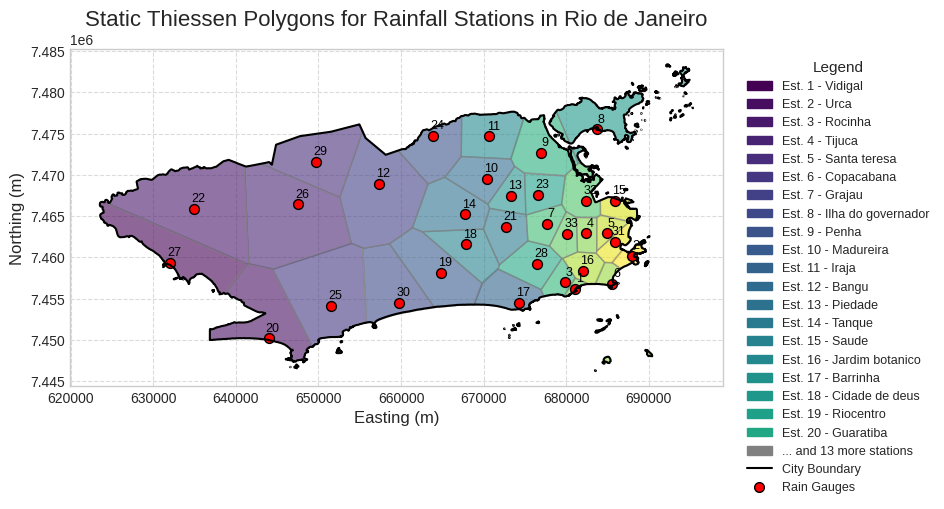

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Plot city boundary (already in projected CRS)
city_boundary_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5, label='City Boundary', zorder=3)

# Plot Thiessen polygons
num_stations_in_polygons = len(thiessen_polygons_gdf['id_estacao'].unique())
cmap_qualitative = plt.get_cmap('viridis', num_stations_in_polygons)

unique_station_ids_in_polygons = sorted(thiessen_polygons_gdf['id_estacao'].unique())
color_map = {station_id: cmap_qualitative(i) for i, station_id in enumerate(unique_station_ids_in_polygons)}

for idx, row in thiessen_polygons_gdf.iterrows():
    gpd.GeoSeries([row.geometry], crs=CRS_PROJECTED).plot(
        ax=ax,
        color=color_map.get(row.id_estacao, 'lightgray'), # Use .get for safety
        edgecolor='gray',
        alpha=0.6,
        zorder=1
    )

# Plot station points (already in projected CRS)
stations_gdf.plot(ax=ax, marker='o', color='red', markersize=50, edgecolor='black', label='Rain Gauges', zorder=2)
for x, y, label in zip(stations_gdf.geometry.x, stations_gdf.geometry.y, stations_gdf.id_estacao):
    ax.text(x + 500, y + 500, label, fontsize=9, ha='center', va='bottom', color='black', zorder=4)

# Create custom legend
station_info_for_legend = stations_gdf.set_index('id_estacao')
legend_patches = []
# Limit legend entries if too many stations for clarity, e.g., max 15-20
max_legend_stations = 20
ids_for_legend = unique_station_ids_in_polygons[:max_legend_stations]

for sid in ids_for_legend:
    station_name = station_info_for_legend.loc[sid, "estacao"] if sid in station_info_for_legend.index else f"Est. {sid}"
    legend_patches.append(mpatches.Patch(color=color_map[sid], label=f'Est. {sid} - {station_name}'))

if len(unique_station_ids_in_polygons) > max_legend_stations:
     legend_patches.append(mpatches.Patch(color='grey', label=f'... and {len(unique_station_ids_in_polygons)-max_legend_stations} more stations'))


legend_patches.append(plt.Line2D([0], [0], color='black', lw=1.5, label='City Boundary'))
legend_patches.append(plt.Line2D([0], [0], marker='o', color='red', markeredgecolor='black', markersize=7, linestyle='None', label='Rain Gauges'))

ax.set_title('Static Thiessen Polygons for Rainfall Stations in Rio de Janeiro', fontsize=16)
ax.set_xlabel('Easting (m)', fontsize=12)
ax.set_ylabel('Northing (m)', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.grid(True, linestyle='--', alpha=0.7)
plt.legend(handles=legend_patches, title="Legend", fontsize=9, title_fontsize=11, loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout(rect=[0, 0, 0.80, 1]) # Adjust layout for legend
plt.show()

#### 1.8.2. Time Series Plot of Areal Average Rainfall

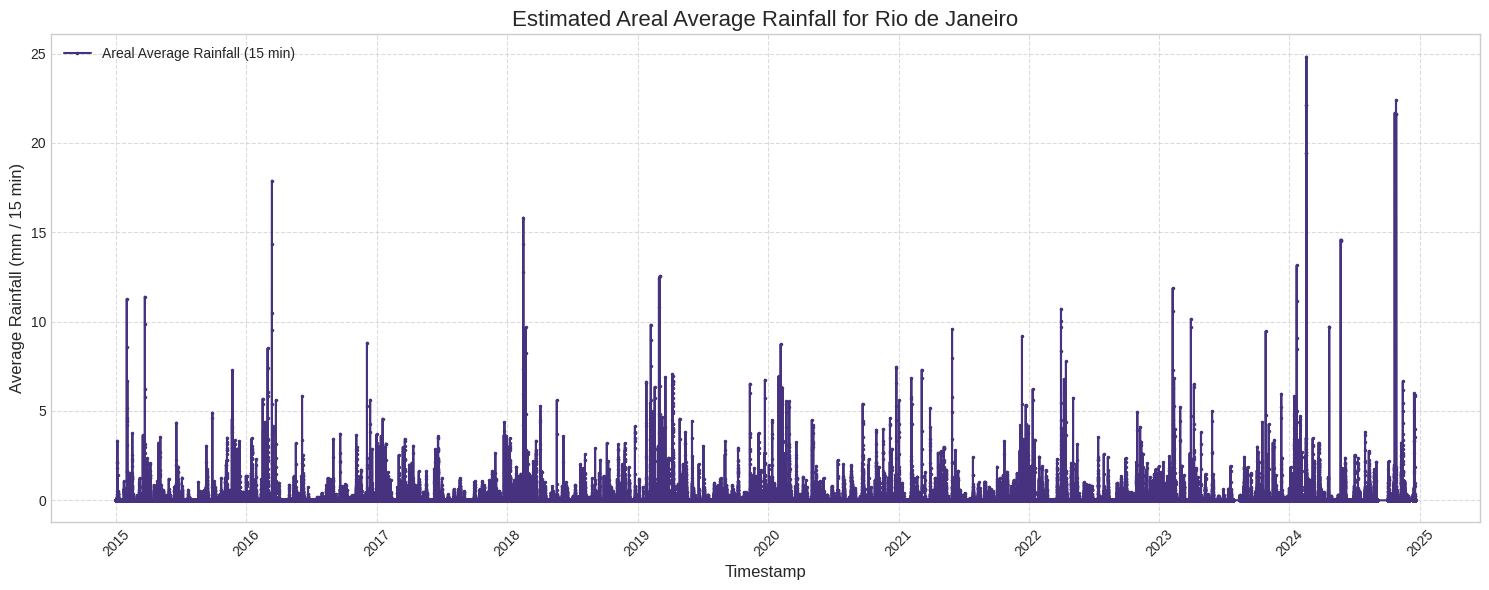


Descriptive statistics for calculated areal average rainfall:


count    395378.000000
mean          0.034451
std           0.260339
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          24.834729
Name: areal_avg_rainfall_mm_15min, dtype: float64

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(areal_rainfall_ts_df['timestamp'], areal_rainfall_ts_df['areal_avg_rainfall_mm_15min'],
         marker='.', linestyle='-', markersize=3, color=sns.color_palette("viridis")[0], label='Areal Average Rainfall (15 min)')

plt.title('Estimated Areal Average Rainfall for Rio de Janeiro', fontsize=16)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Average Rainfall (mm / 15 min)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nDescriptive statistics for calculated areal average rainfall:")
display(areal_rainfall_ts_df['areal_avg_rainfall_mm_15min'].describe())

### 1.9. Save Outputs from Part 1

In [ ]:
# Save Thiessen Polygons GeoDataFrame
thiessen_output_path = os.path.join(OUTPUT_DATA_DIRECTORY, THIESSEN_POLYGONS_FILENAME)
try:
    cols_to_save = ['id_estacao', 'estacao', 'area_m2', 'weight', 'geometry']
    # Ensure all columns exist before trying to save
    thiessen_polygons_to_save = thiessen_polygons_gdf[[col for col in cols_to_save if col in thiessen_polygons_gdf.columns]].copy()
    if 'geometry' in thiessen_polygons_to_save.columns:
        thiessen_polygons_to_save.to_file(thiessen_output_path, driver="GPKG")
        print(f"\nThiessen polygons saved to: {thiessen_output_path}")
    else:
        print("Error: 'geometry' column missing, cannot save Thiessen polygons.")
except Exception as e:
    print(f"Error saving Thiessen polygons: {e}")

# Save Areal Rainfall Time Series
areal_rainfall_output_path = os.path.join(OUTPUT_DATA_DIRECTORY, AREAL_RAINFALL_FILENAME)
try:
    areal_rainfall_ts_df.to_csv(areal_rainfall_output_path, index=False)
    print(f"Areal rainfall time series saved to: {areal_rainfall_output_path}")
except Exception as e:
    print(f"Error saving areal rainfall time series: {e}")


Thiessen polygons saved to: ../../../../data/meteorologia/processed/thiessen_analysis/thiessen_polygons_rio.gpkg
Areal rainfall time series saved to: ../../../../data/meteorologia/processed/thiessen_analysis/areal_rainfall_15min_rio.csv


### 1.10. Conclusion for Part 1

This part successfully demonstrated the workflow for calculating areal average rainfall using static Thiessen polygons. Key steps included data loading and preprocessing, CRS transformation, polygon generation and weighting, and finally, the computation and visualization of the areal rainfall time series.

The resulting `areal_rainfall_ts_df` will serve as the primary input for the subsequent advanced rainfall event analysis in Part 2.

**Note on Areal Coverage:** The areal average rainfall calculated pertains to the portion of Rio de Janeiro covered by the generated Thiessen polygons. This coverage is determined by the distribution of active rain gauges. Consequently, "city-wide" rainfall in this analysis refers to this specific covered area.

---

## Part 2: Advanced Rainfall Event Analysis

This section delves deeper into the `areal_rainfall_ts_df` (areal average rainfall) to identify and characterize periods of significant rainfall. We will employ three distinct methodologies: daily aggregation, continuous rain period identification, and Peak Over Threshold (POT) analysis.

### 2.1. Data Regularization and Preparation

The `areal_rainfall_ts_df` might have irregular timestamps if raw data logging varies. For robust event analysis, especially methods relying on consecutive periods or `shift()` operations, we need to regularize the time series to a constant 15-minute frequency.

In [ ]:
# Ensure areal_rainfall_ts_df is available (it should be from Part 1)
if 'areal_rainfall_ts_df' not in locals():
    # Attempt to load if running this part standalone (adjust path if needed)
    try:
        areal_rainfall_path_check = os.path.join(OUTPUT_DATA_DIRECTORY, AREAL_RAINFALL_FILENAME)
        areal_rainfall_ts_df = pd.read_csv(areal_rainfall_path_check)
        if 'timestamp' in areal_rainfall_ts_df.columns:
             areal_rainfall_ts_df['timestamp'] = pd.to_datetime(areal_rainfall_ts_df['timestamp'])
        print(f"Loaded areal_rainfall_ts_df from {areal_rainfall_path_check}")
    except FileNotFoundError:
        raise FileNotFoundError(f"Areal rainfall data not found at {areal_rainfall_path_check}. Run Part 1 first.")


# Set timestamp as index for resampling
if not isinstance(areal_rainfall_ts_df.index, pd.DatetimeIndex):
    areal_rainfall_ts_df_indexed = areal_rainfall_ts_df.set_index('timestamp')
else:
    areal_rainfall_ts_df_indexed = areal_rainfall_ts_df.copy()


# Regularize to 15-minute frequency.
# Values in 'areal_avg_rainfall_mm_15min' are accumulations for 15-min periods.
# Resampling and summing is appropriate. Fill NaNs (intervals with no original data) with 0.
areal_rainfall_15T_df = areal_rainfall_ts_df_indexed['areal_avg_rainfall_mm_15min'].resample('15T').sum().fillna(0).reset_index()
areal_rainfall_15T_df.rename(columns={'areal_avg_rainfall_mm_15min': 'rainfall_mm_15min'}, inplace=True)

print("Regularized Areal Rainfall Time Series (first 5 rows):")
display(areal_rainfall_15T_df.head())
print(f"\nNumber of 15-minute intervals in regularized data: {len(areal_rainfall_15T_df)}")
if not areal_rainfall_15T_df.empty:
    print(f"Time range: {areal_rainfall_15T_df['timestamp'].min()} to {areal_rainfall_15T_df['timestamp'].max()}")
else:
    print("Regularized data is empty.")


# Basic statistics of the regularized series
print("\nDescriptive statistics for regularized 15-min areal rainfall:")
display(areal_rainfall_15T_df['rainfall_mm_15min'].describe())

Regularized Areal Rainfall Time Series (first 5 rows):


/tmp/ipykernel_51524/2956486642.py:24: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  areal_rainfall_15T_df = areal_rainfall_ts_df_indexed['areal_avg_rainfall_mm_15min'].resample('15T').sum().fillna(0).reset_index()


,timestamp,rainfall_mm_15min
0,2015-01-01 00:00:00,0.0
1,2015-01-01 00:15:00,0.0
2,2015-01-01 00:30:00,0.0
3,2015-01-01 00:45:00,0.0
4,2015-01-01 01:00:00,0.0



Number of 15-minute intervals in regularized data: 349316
Time range: 2015-01-01 00:00:00 to 2024-12-17 16:45:00

Descriptive statistics for regularized 15-min areal rainfall:


count    349316.000000
mean          0.038994
std           0.306379
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          49.669459
Name: rainfall_mm_15min, dtype: float64

### 2.2. Analysis 1: Daily Rainfall Aggregation

This analysis focuses on identifying days with rainfall and quantifying the total rainfall for those days.

In [ ]:
# Aggregate 15-minute data to daily totals
daily_rainfall_df = areal_rainfall_15T_df.set_index('timestamp')['rainfall_mm_15min'].resample('D').sum().reset_index()
daily_rainfall_df.rename(columns={'rainfall_mm_15min': 'total_daily_rainfall_mm'}, inplace=True)

# Identify rainy days
MIN_RAIN_FOR_RAINY_DAY = 0.01 # mm threshold to count as a rainy day
rainy_days_df = daily_rainfall_df[daily_rainfall_df['total_daily_rainfall_mm'] > MIN_RAIN_FOR_RAINY_DAY].copy()

print(f"Total number of days in the dataset: {len(daily_rainfall_df)}")
print(f"Number of days with rainfall (> {MIN_RAIN_FOR_RAINY_DAY} mm): {len(rainy_days_df)}")
if len(daily_rainfall_df) > 0:
    print(f"Percentage of rainy days: {(len(rainy_days_df) / len(daily_rainfall_df) * 100):.2f}%")

# Days with the most rain
TOP_N_DAYS = 10
most_rainy_days = rainy_days_df.sort_values(by='total_daily_rainfall_mm', ascending=False).head(TOP_N_DAYS)

print(f"\nTop {TOP_N_DAYS} days with the most areal rainfall:")
display(most_rainy_days)

Total number of days in the dataset: 3639
Number of days with rainfall (> 0.01 mm): 1860
Percentage of rainy days: 51.11%

Top 10 days with the most areal rainfall:


,timestamp,total_daily_rainfall_mm
3368,2024-03-22,177.706259
3509,2024-08-10,129.696627
3334,2024-02-17,113.408959
1558,2019-04-08,108.144412
1559,2019-04-09,103.245856
3332,2024-02-15,97.449889
3580,2024-10-20,96.768693
2091,2020-09-22,95.541436
3604,2024-11-13,85.594215
2959,2023-02-07,85.464784


#### Visualizations for Daily Rainfall

/tmp/ipykernel_51524/3042278943.py:4: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  sample_period_daily_plot = sample_period_daily_plot.last('730D') # Use .iloc[-730:] for newer pandas


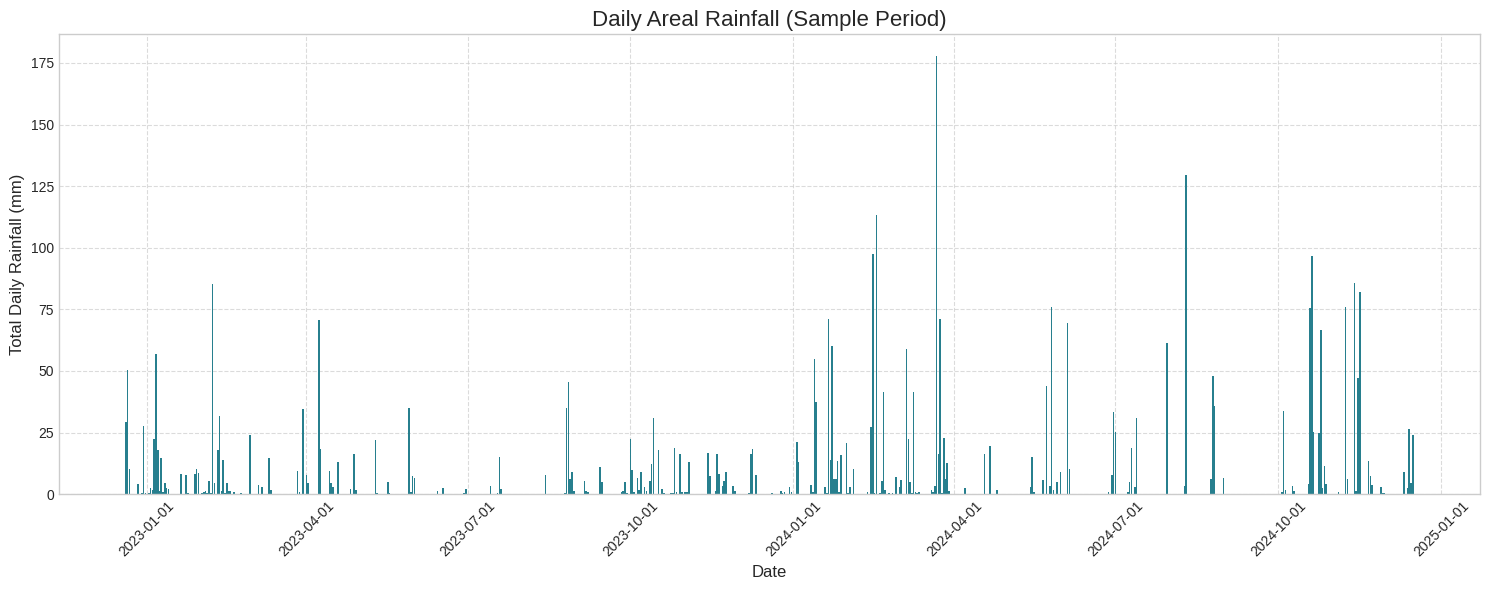

/tmp/ipykernel_51524/3042278943.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_daily_rainfall_mm', y=most_rainy_days['timestamp'].dt.strftime('%Y-%m-%d'),


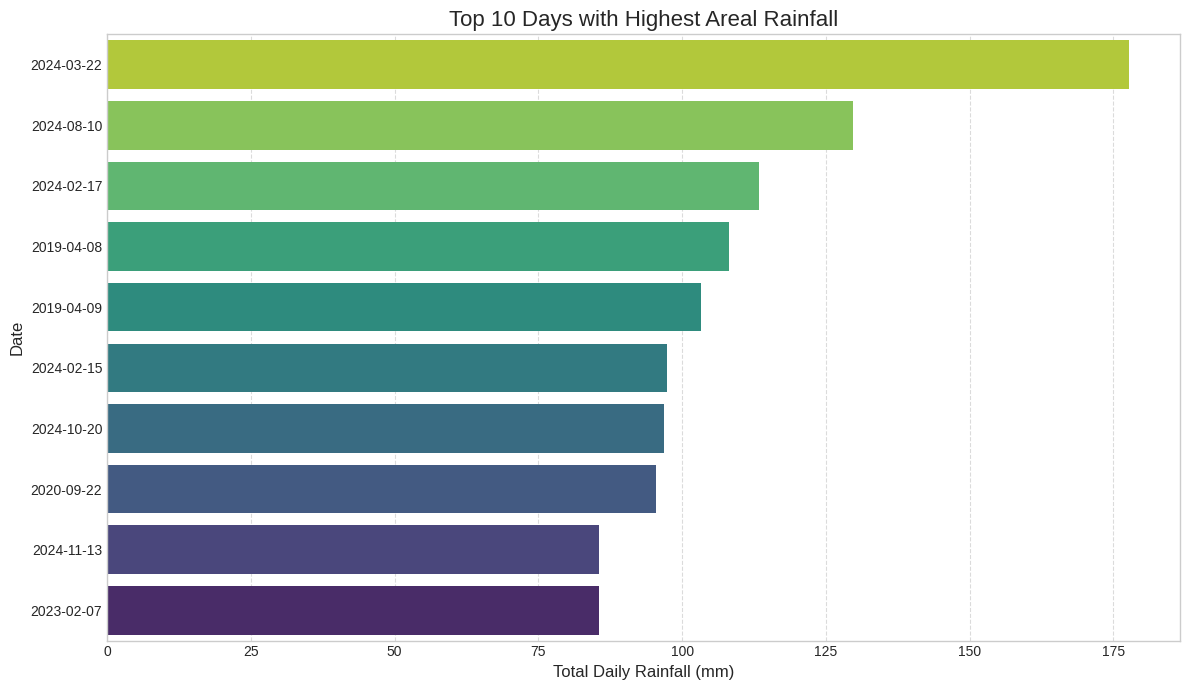

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


<Figure size 1600x1000 with 0 Axes>

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


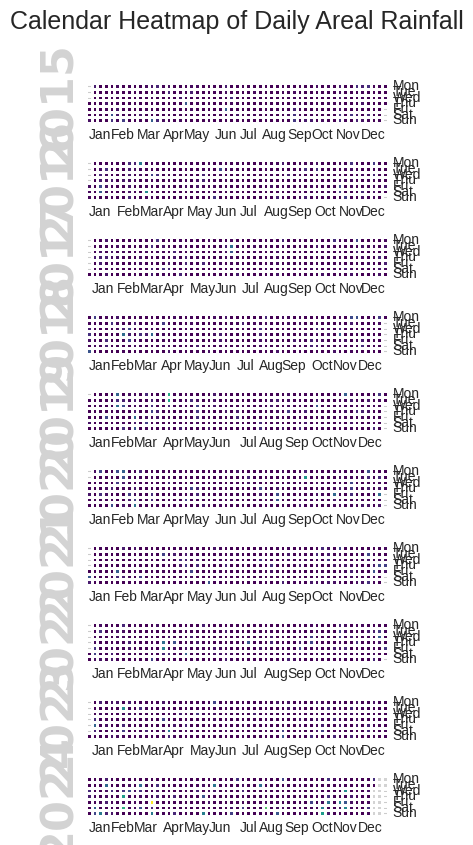

In [ ]:
# Plot 1: Time Series of Daily Rainfall (Sample: last 2 years if data is long)
sample_period_daily_plot = daily_rainfall_df.set_index('timestamp')
if len(sample_period_daily_plot) > 365 * 2:
    sample_period_daily_plot = sample_period_daily_plot.last('730D') # Use .iloc[-730:] for newer pandas

plt.figure(figsize=(15, 6))
plt.bar(sample_period_daily_plot.index, sample_period_daily_plot['total_daily_rainfall_mm'],
        color=sns.color_palette("viridis")[2], width=0.9)
plt.title(f'Daily Areal Rainfall (Sample Period)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Daily Rainfall (mm)', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot 2: Bar Chart of Top N Rainy Days
plt.figure(figsize=(12, 7))
sns.barplot(x='total_daily_rainfall_mm', y=most_rainy_days['timestamp'].dt.strftime('%Y-%m-%d'),
            data=most_rainy_days, palette='viridis_r', orient='h')
plt.title(f'Top {TOP_N_DAYS} Days with Highest Areal Rainfall', fontsize=16)
plt.xlabel('Total Daily Rainfall (mm)', fontsize=12)
plt.ylabel('Date', fontsize=12)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot 3: Calendar Heatmap (if calmap is available)
if calmap and not daily_rainfall_df.empty and len(daily_rainfall_df) > 30 :
    plt.figure(figsize=(16,10)) # Adjust figure size as needed
    daily_rainfall_series_for_calmap = daily_rainfall_df.set_index('timestamp')['total_daily_rainfall_mm']

    unique_years = daily_rainfall_series_for_calmap.index.year.unique()
    years_to_plot = sorted(unique_years, reverse=True)[:min(3, len(unique_years))] # Plot last 3 years max

    if not daily_rainfall_series_for_calmap[daily_rainfall_series_for_calmap.index.year.isin(years_to_plot)].empty:
        try:
            # For multiple years, calmap plots them sequentially.
            # If single year, specify year=years_to_plot[0]
            calmap.calendarplot(daily_rainfall_series_for_calmap, # Use calendarplot for multi-year overview
                                yearlabels=True, yearascending=True,
                                cmap='viridis', fillcolor='lightgrey', linewidth=1, fig_kws={'figsize': (30, 16)})

            plt.suptitle('Calendar Heatmap of Daily Areal Rainfall', fontsize=18, y=1.05)
            plt.show()
        except Exception as e:
            print(f"Could not generate calendar heatmap: {e}")
    else:
        print("Not enough data in the selected years for calendar heatmap after filtering.")
else:
    if not calmap: print("Skipping calendar heatmap: 'calmap' library not installed or imported.")
    else: print("Skipping calendar heatmap: Insufficient data length.")

### 2.3. Analysis 2: Continuous Rainfall Period Identification (Rain Events)

This analysis identifies "rain events" as continuous periods of rainfall, allowing for short dry interruptions.

In [ ]:
def identify_rain_events(rainfall_series, rain_threshold, min_dry_spell_duration_for_separation):
    """Identifies continuous rain events from a rainfall time series.
    (Docstring from original notebook retained)
    """
    df = rainfall_series.to_frame()
    col_name = rainfall_series.name if rainfall_series.name else 'rainfall'
    df.rename(columns={col_name:'rainfall'}, inplace=True)

    df['is_raining'] = df['rainfall'] > rain_threshold
    
    df['block_change'] = df['is_raining'].diff().fillna(False)
    df['block_id'] = df['block_change'].cumsum()

    events = []
    current_event_id_counter = 0
    
    if df.index.empty: # Handle empty input series
        return pd.DataFrame(columns=['event_id', 'start_time', 'end_time', 'duration', 
                                     'total_rainfall_mm', 'peak_15min_intensity_mm', 'avg_intensity_mm_hr'])
                                     
    inferred_interval = pd.Timedelta(minutes=15) # Default
    if len(df.index) > 1:
        inferred_interval = df.index[1] - df.index[0]


    for block_id, group in df.groupby('block_id'):
        if not group['is_raining'].any():
            continue

        start_time = group.index.min()
        end_time = group.index.max()
        
        if not events:
            current_event_id_counter += 1
            current_event = {
                'event_id': current_event_id_counter,
                'start_time': start_time,
                'end_time': end_time, 
                'rain_periods': [(start_time, end_time)]
            }
            events.append(current_event)
        else:
            last_event = events[-1]
            time_since_last_rain = start_time - last_event['rain_periods'][-1][1]
            actual_dry_spell_duration = time_since_last_rain - inferred_interval
            
            if actual_dry_spell_duration <= min_dry_spell_duration_for_separation:
                last_event['end_time'] = end_time
                last_event['rain_periods'].append((start_time, end_time))
            else:
                current_event_id_counter += 1
                current_event = {
                    'event_id': current_event_id_counter,
                    'start_time': start_time,
                    'end_time': end_time,
                    'rain_periods': [(start_time, end_time)]
                }
                events.append(current_event)

    if not events:
        return pd.DataFrame(columns=['event_id', 'start_time', 'end_time', 'duration', 
                                     'total_rainfall_mm', 'peak_15min_intensity_mm', 'avg_intensity_mm_hr'])

    event_summary_list = []
    for event_data in events:
        true_event_end_time = event_data['end_time'] + inferred_interval
        duration = true_event_end_time - event_data['start_time']
        
        event_rainfall_series = rainfall_series.loc[event_data['start_time']:event_data['end_time']]
        total_rainfall = event_rainfall_series.sum()
        peak_intensity = event_rainfall_series.max()
        
        duration_hours = duration.total_seconds() / 3600
        avg_intensity_mm_hr = total_rainfall / duration_hours if duration_hours > 0 else 0
        
        event_summary_list.append({
            'event_id': event_data['event_id'],
            'start_time': event_data['start_time'],
            'end_time': true_event_end_time,
            'duration': duration,
            'total_rainfall_mm': total_rainfall,
            'peak_15min_intensity_mm': peak_intensity,
            'avg_intensity_mm_hr': avg_intensity_mm_hr
        })
        
    events_df = pd.DataFrame(event_summary_list)
    return events_df

# Parameters for rain event definition
RAIN_THRESHOLD_FOR_EVENT = 0.01  # mm in a 15-min interval
MIN_DRY_SPELL_HOURS = 1       # Hours of no/negligible rain to separate events
MIN_DRY_SPELL_DURATION = pd.Timedelta(hours=MIN_DRY_SPELL_HOURS)

# Prepare series for event identification
rainfall_series_for_events = areal_rainfall_15T_df.set_index('timestamp')['rainfall_mm_15min']

# Identify events
rain_events_df = identify_rain_events(rainfall_series_for_events,
                                      RAIN_THRESHOLD_FOR_EVENT,
                                      MIN_DRY_SPELL_DURATION)

print(f"\nIdentified {len(rain_events_df)} rain events (separation: {MIN_DRY_SPELL_HOURS} dry hours).")
if not rain_events_df.empty:
    print("Summary of identified rain events:")
    display(rain_events_df.describe(percentiles=[.5, .75, .9, .95, .99]))

    TOP_N_EVENTS = 10
    most_intense_events = rain_events_df.sort_values(by='total_rainfall_mm', ascending=False).head(TOP_N_EVENTS)
    print(f"\nTop {TOP_N_EVENTS} rain events by total rainfall:")
    display(most_intense_events[['event_id', 'start_time', 'end_time', 'duration', 'total_rainfall_mm', 'peak_15min_intensity_mm']])
else:
    print("No rain events identified with the current parameters.")
    most_intense_events = pd.DataFrame() # Ensure it's defined for later

/tmp/ipykernel_51524/1731543616.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['block_change'] = df['is_raining'].diff().fillna(False)



Identified 2966 rain events (separation: 1 dry hours).
Summary of identified rain events:


,event_id,start_time,end_time,duration,total_rainfall_mm,peak_15min_intensity_mm,avg_intensity_mm_hr
count,2966.000000,2966,2966,2966,2966.000000,2966.000000,2966.000000
mean,1483.500000,2019-12-27 07:47:38.091705856,2019-12-27 11:53:16.122724096,0 days 04:05:38.031018206,4.577506,0.659293,0.641393
min,1.000000,2015-01-01 20:30:00,2015-01-01 21:15:00,0 days 00:15:00,0.010075,0.010075,0.019520
50%,1483.500000,2020-01-31 05:22:30,2020-01-31 08:37:30,0 days 01:30:00,0.220932,0.081584,0.144429
75%,2224.750000,2022-05-12 09:07:30,2022-05-12 12:22:30,0 days 04:30:00,2.238156,0.454560,0.500158
90%,2669.500000,2023-11-18 21:07:30,2023-11-18 22:22:30,0 days 10:30:00,11.977403,1.605920,1.347895
95%,2817.750000,2024-03-29 05:11:15,2024-03-29 11:37:30,0 days 16:56:15,24.235199,3.229835,2.345439
99%,2936.350000,2024-11-18 12:45:45,2024-11-18 17:26:15,1 days 10:05:59.999999999,72.091597,8.767917,5.079646
max,2966.000000,2024-12-16 21:30:00,2024-12-16 22:00:00,2 days 19:45:00,233.785435,49.669459,113.402363
std,856.354775,NaN,NaN,0 days 06:57:14.119382455,13.772621,1.977855,3.545295



Top 10 rain events by total rainfall:


,event_id,start_time,end_time,duration,total_rainfall_mm,peak_15min_intensity_mm
1267,1268,2019-04-08 15:15:00,2019-04-11 05:30:00,2 days 14:15:00,233.785435,7.074515
2801,2802,2024-03-22 07:45:00,2024-03-23 03:45:00,0 days 20:00:00,181.298409,8.979934
2905,2906,2024-10-19 14:45:00,2024-10-20 21:30:00,1 days 06:45:00,171.301771,5.679691
2886,2887,2024-08-09 21:30:00,2024-08-10 18:30:00,0 days 21:00:00,132.860516,7.661518
1638,1639,2020-09-21 18:45:00,2020-09-23 04:30:00,1 days 09:45:00,113.902983,5.406913
2753,2754,2024-02-17 10:45:00,2024-02-17 11:45:00,0 days 01:00:00,113.402363,49.669459
1495,1496,2020-02-10 14:30:00,2020-02-13 07:15:00,2 days 16:45:00,108.871639,6.310951
1519,1520,2020-02-29 19:45:00,2020-03-02 00:45:00,1 days 05:00:00,99.478772,5.558529
2431,2432,2023-01-05 06:00:00,2023-01-08 01:45:00,2 days 19:45:00,97.584753,1.606498
2749,2750,2024-02-15 08:00:00,2024-02-16 01:15:00,0 days 17:15:00,91.403778,9.195042


#### Visualizations for Rain Events

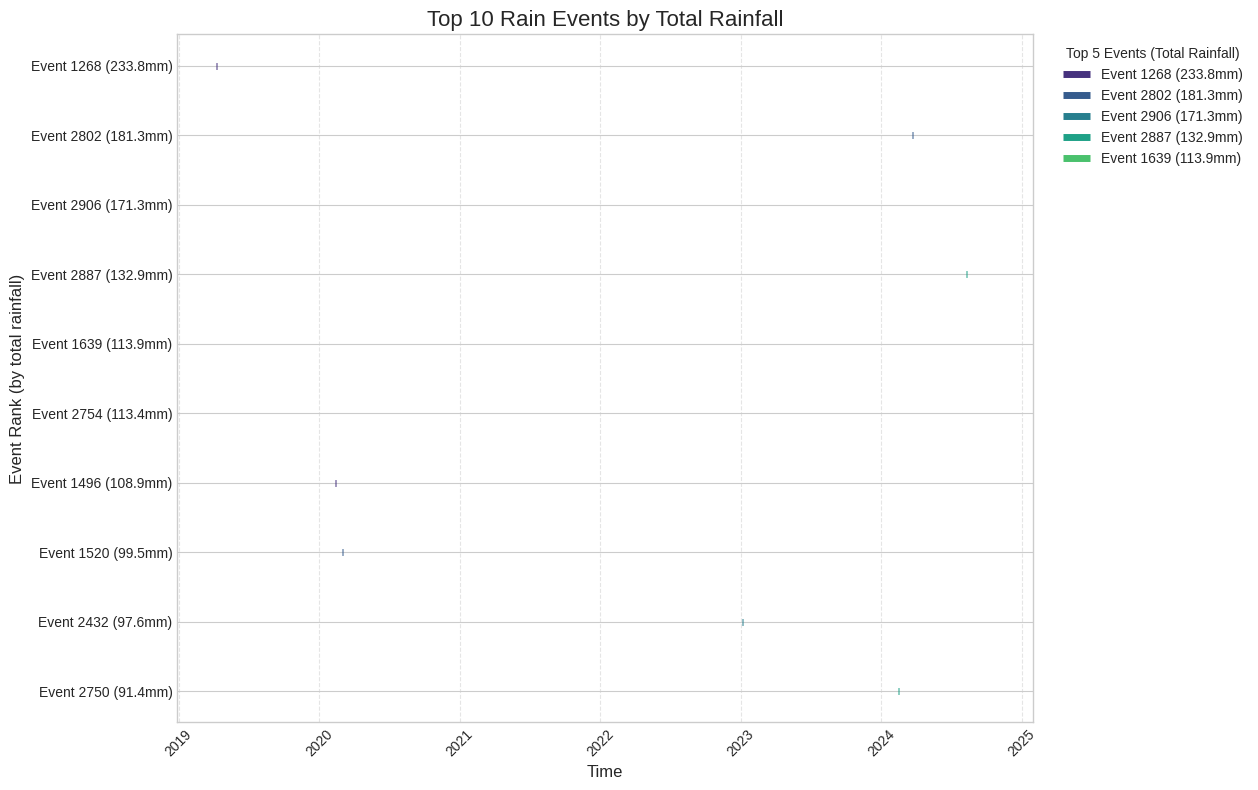

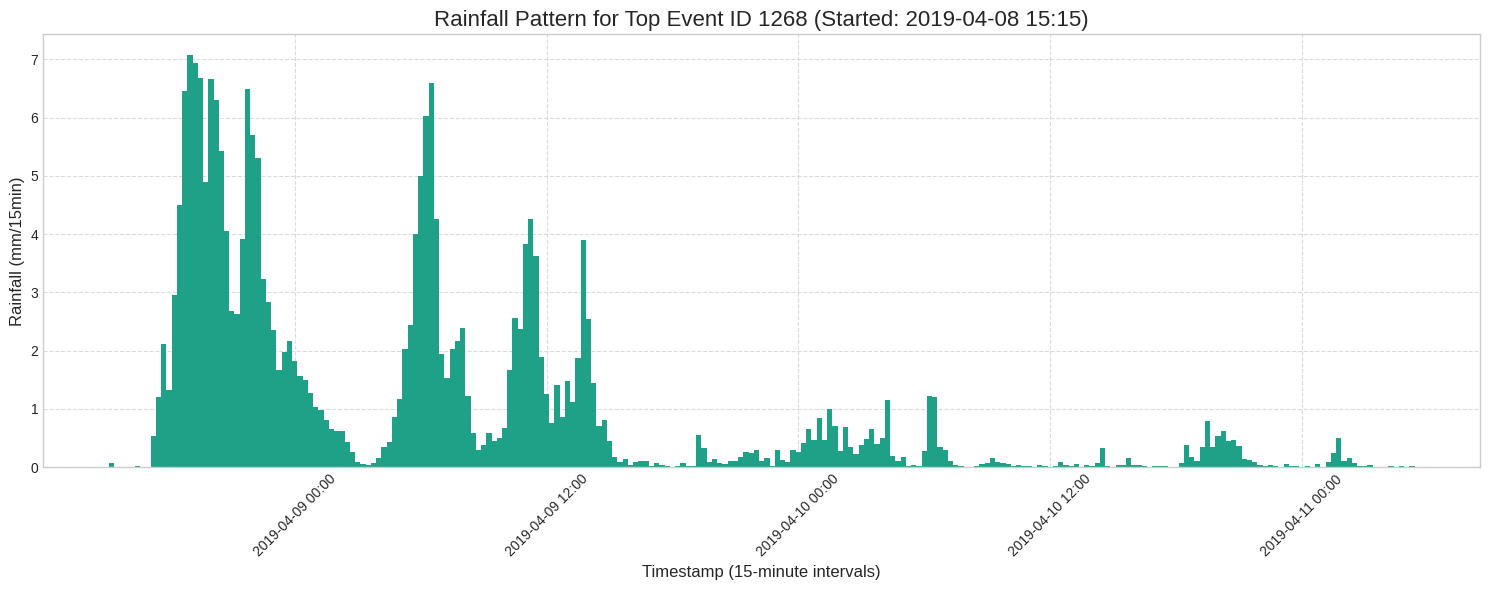

In [ ]:
if not rain_events_df.empty and not most_intense_events.empty:
    # Plot 1: Gantt-like chart of Top N Rain Events
    plt.figure(figsize=(15, 8))
    for i, (_, event_row) in enumerate(most_intense_events.iterrows()): # Use enumerate for y-position
        plt.plot([event_row['start_time'], event_row['end_time']], [i, i],
                 linewidth=5, solid_capstyle='butt',
                 label=f"Event {event_row['event_id']} ({event_row['total_rainfall_mm']:.1f}mm)" if i < 5 else None) # Label first 5

    plt.yticks(range(len(most_intense_events)),
               [f"Event {eid} ({vol:.1f}mm)" for eid, vol in zip(most_intense_events['event_id'], most_intense_events['total_rainfall_mm'])])
    plt.gca().invert_yaxis()

    plt.title(f'Top {len(most_intense_events)} Rain Events by Total Rainfall', fontsize=16)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Event Rank (by total rainfall)', fontsize=12)
    plt.xticks(rotation=45)
    # Create a simpler legend if too many items are labeled
    handles, labels = plt.gca().get_legend_handles_labels()
    if handles: # only show legend if items were labeled
        plt.legend(title="Top 5 Events (Total Rainfall)", bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5, axis='x')
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

    # Plot 2: Rainfall Pattern for the Top Event
    top_event_details = most_intense_events.iloc[0]
    plt.figure(figsize=(15, 6))
    event_period_data = areal_rainfall_15T_df[
        (areal_rainfall_15T_df['timestamp'] >= top_event_details['start_time']) &
        (areal_rainfall_15T_df['timestamp'] < top_event_details['end_time'])
    ]
    plt.bar(event_period_data['timestamp'], event_period_data['rainfall_mm_15min'],
            width=pd.Timedelta(minutes=15)/pd.Timedelta(days=1), # width as fraction of a day for mdates
            color=sns.color_palette("viridis")[3])

    plt.title(f"Rainfall Pattern for Top Event ID {top_event_details['event_id']} (Started: {top_event_details['start_time']:%Y-%m-%d %H:%M})", fontsize=16)
    plt.xlabel('Timestamp (15-minute intervals)', fontsize=12)
    plt.ylabel('Rainfall (mm/15min)', fontsize=12)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping event visualizations as no significant events were identified or data is insufficient.")

### 2.4. Analysis 3: Peak Over Threshold (POT) Event Analysis

This method identifies "extreme" rainfall periods by selecting intensities exceeding a defined threshold.

In [ ]:
def identify_pot_events(rainfall_series, pot_threshold, min_exceedance_intervals, max_time_between_exceedances_for_clustering):
    """Identifies Peak Over Threshold (POT) events.
    (Docstring from original notebook retained)
    """
    df = rainfall_series.to_frame()
    col_name = rainfall_series.name if rainfall_series.name else 'rainfall'
    df.rename(columns={col_name:'rainfall'}, inplace=True)

    if df.empty: # Handle empty input series
        return pd.DataFrame()
        
    df['is_exceedance'] = df['rainfall'] > pot_threshold
    
    df['exceedance_block_id'] = (df['is_exceedance'] != df['is_exceedance'].shift()).cumsum()
    block_counts = df.groupby('exceedance_block_id')['is_exceedance'].count() # Correctly counts intervals in block
    
    valid_exceedance_blocks = df[df['is_exceedance']]['exceedance_block_id'].unique()
    
    filtered_exceedance_ids = []
    for block_id_val in valid_exceedance_blocks: # Renamed variable to avoid conflict
        # Check if this block_id_val corresponds to an actual exceedance period
        # and if its count (duration) meets the minimum
        if df[df['exceedance_block_id'] == block_id_val]['is_exceedance'].all() and \
           block_counts.get(block_id_val, 0) >= min_exceedance_intervals:
            filtered_exceedance_ids.append(block_id_val)
            
    df['is_valid_exceedance_period'] = df['exceedance_block_id'].isin(filtered_exceedance_ids)

    df['pot_event_change'] = df['is_valid_exceedance_period'].diff().fillna(False)
    df['pot_block_id'] = df['pot_event_change'].cumsum()

    pot_events = []
    current_pot_event_id_counter = 0
    inferred_interval = pd.Timedelta(minutes=15) # Default
    if len(df.index) > 1:
         inferred_interval = df.index[1] - df.index[0]

    for block_id_val, group in df.groupby('pot_block_id'): # Renamed variable
        if not group['is_valid_exceedance_period'].any():
            continue

        start_time = group.index.min()
        end_time = group.index.max()
        
        if not pot_events:
            current_pot_event_id_counter += 1
            current_pot_event = {
                'pot_event_id': current_pot_event_id_counter,
                'start_time': start_time,
                'end_time': end_time,
                'exceedance_periods': [(start_time, end_time)]
            }
            pot_events.append(current_pot_event)
        else:
            last_pot_event = pot_events[-1]
            time_since_last_exceedance_block = start_time - last_pot_event['exceedance_periods'][-1][1]
            actual_gap_duration = time_since_last_exceedance_block - inferred_interval
            
            if actual_gap_duration <= max_time_between_exceedances_for_clustering:
                last_pot_event['end_time'] = end_time
                last_pot_event['exceedance_periods'].append((start_time, end_time))
            else:
                current_pot_event_id_counter += 1
                current_pot_event = {
                    'pot_event_id': current_pot_event_id_counter,
                    'start_time': start_time,
                    'end_time': end_time,
                    'exceedance_periods': [(start_time, end_time)]
                }
                pot_events.append(current_pot_event)
    
    if not pot_events:
         return pd.DataFrame()

    pot_event_summary_list = []
    for pot_event_data in pot_events:
        true_pot_event_start_time = pot_event_data['start_time']
        true_pot_event_end_time = pot_event_data['end_time'] + inferred_interval
        duration_of_exceedance_phase = true_pot_event_end_time - true_pot_event_start_time
        
        exceedance_phase_rainfall_series = rainfall_series.loc[true_pot_event_start_time : pot_event_data['end_time']]
        total_rainfall_during_exceedance = exceedance_phase_rainfall_series.sum()
        peak_15min_intensity_during_exceedance = exceedance_phase_rainfall_series.max()
        
        exceeding_intervals_series = exceedance_phase_rainfall_series[exceedance_phase_rainfall_series > pot_threshold]
        magnitude_over_threshold = (exceeding_intervals_series - pot_threshold).sum()
        num_exceeding_intervals = len(exceeding_intervals_series)

        pot_event_summary_list.append({
            'pot_event_id': pot_event_data['pot_event_id'],
            'start_time': true_pot_event_start_time,
            'end_time': true_pot_event_end_time,
            'duration_exceedance_phase': duration_of_exceedance_phase,
            'num_exceeding_intervals': num_exceeding_intervals,
            'total_rainfall_during_exceedance_phase': total_rainfall_during_exceedance,
            'peak_15min_intensity_during_exceedance_phase': peak_15min_intensity_during_exceedance,
            'magnitude_over_threshold_mm': magnitude_over_threshold
        })
        
    pot_events_df = pd.DataFrame(pot_event_summary_list)
    return pot_events_df

# Parameters for POT analysis
non_zero_rainfall = rainfall_series_for_events[rainfall_series_for_events > RAIN_THRESHOLD_FOR_EVENT] # Use same threshold as rain events for consistency
if not non_zero_rainfall.empty:
    POT_INTENSITY_THRESHOLD = non_zero_rainfall.quantile(0.95) # 95th percentile of "rainy" 15-min intervals
else:
    POT_INTENSITY_THRESHOLD = 1.0 # Fallback (mm/15min)
print(f"POT Intensity Threshold (95th percentile of rainy intervals): {POT_INTENSITY_THRESHOLD:.2f} mm/15min")

MIN_EXCEEDANCE_INTERVALS = 2  # Min 2 consecutive 15-min intervals (30 mins)
MAX_TIME_BETWEEN_EXCEEDANCES_HOURS = 3 # Max 3 hours gap to cluster exceedances
MAX_TIME_BETWEEN_EXCEEDANCES = pd.Timedelta(hours=MAX_TIME_BETWEEN_EXCEEDANCES_HOURS)

pot_events_df = identify_pot_events(rainfall_series_for_events,
                                    POT_INTENSITY_THRESHOLD,
                                    MIN_EXCEEDANCE_INTERVALS,
                                    MAX_TIME_BETWEEN_EXCEEDANCES)

print(f"\nIdentified {len(pot_events_df)} POT events.")
if not pot_events_df.empty:
    print("Summary of identified POT events:")
    display(pot_events_df.describe(percentiles=[.5, .75, .9, .95, .99]))

    TOP_N_POT_EVENTS = 10
    most_significant_pot_events = pot_events_df.sort_values(by='magnitude_over_threshold_mm', ascending=False).head(TOP_N_POT_EVENTS)
    print(f"\nTop {TOP_N_POT_EVENTS} POT events by magnitude over threshold:")
    display(most_significant_pot_events)
else:
    print("No POT events identified (threshold might be too high or data lacks such extremes).")
    most_significant_pot_events = pd.DataFrame() # Ensure it's defined

POT Intensity Threshold (95th percentile of rainy intervals): 1.28 mm/15min


/tmp/ipykernel_51524/3361726763.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['pot_event_change'] = df['is_valid_exceedance_period'].diff().fillna(False)



Identified 303 POT events.
Summary of identified POT events:


,pot_event_id,start_time,end_time,duration_exceedance_phase,num_exceeding_intervals,total_rainfall_during_exceedance_phase,peak_15min_intensity_during_exceedance_phase,magnitude_over_threshold_mm
count,303.000000,303,303,303,303.000000,303.000000,303.000000,303.000000
mean,152.000000,2020-03-29 06:42:43.366336512,2020-03-29 08:37:22.574257408,0 days 01:54:39.207920792,6.372937,19.232635,4.375305,10.155420
min,1.000000,2015-01-04 23:30:00,2015-01-05 00:30:00,0 days 00:30:00,2.000000,2.596352,1.302486,0.029608
50%,152.000000,2020-02-29 20:45:00,2020-03-01 04:00:00,0 days 01:00:00,4.000000,10.896304,3.223266,4.725506
75%,227.500000,2023-01-02 18:07:30,2023-01-02 19:07:30,0 days 02:15:00,7.000000,23.071129,5.173527,12.679904
90%,272.800000,2024-03-04 10:57:00,2024-03-04 15:27:00,0 days 04:30:00,13.600000,44.509746,7.624205,24.767580
95%,287.900000,2024-07-13 06:09:00,2024-07-13 06:42:00,0 days 05:45:00,18.000000,64.441983,10.789248,41.206556
99%,299.980000,2024-11-15 23:25:12,2024-11-16 04:05:42,0 days 10:14:06,29.960000,113.358347,17.889481,68.204745
max,303.000000,2024-12-16 15:45:00,2024-12-16 16:30:00,0 days 17:15:00,54.000000,175.878453,49.669459,108.268875
std,87.612784,NaN,NaN,0 days 02:15:07.199606722,6.717788,22.907575,4.238475,14.769601



Top 10 POT events by magnitude over threshold:


,pot_event_id,start_time,end_time,duration_exceedance_phase,num_exceeding_intervals,total_rainfall_during_exceedance_phase,peak_15min_intensity_during_exceedance_phase,magnitude_over_threshold_mm
269,270,2024-02-17 10:45:00,2024-02-17 11:45:00,0 days 01:00:00,4,113.402363,49.669459,108.268875
274,275,2024-03-22 09:00:00,2024-03-23 00:00:00,0 days 15:00:00,50,175.878453,8.979934,102.899443
123,124,2019-04-08 17:45:00,2019-04-09 00:45:00,0 days 07:00:00,28,111.201546,7.074515,75.267127
292,293,2024-10-19 16:15:00,2024-10-20 09:30:00,0 days 17:15:00,54,153.051706,5.679691,68.384223
44,45,2016-03-12 19:15:00,2016-03-12 22:00:00,0 days 02:45:00,11,73.527395,17.890309,59.410302
296,297,2024-11-13 08:30:00,2024-11-13 11:15:00,0 days 02:45:00,11,71.003818,17.848911,56.886725
289,290,2024-08-10 01:15:00,2024-08-10 15:15:00,0 days 14:00:00,45,121.152891,7.661518,54.031798
230,231,2023-02-07 17:00:00,2023-02-07 20:45:00,0 days 03:45:00,15,72.383905,12.434126,53.133324
268,269,2024-02-15 09:30:00,2024-02-15 17:15:00,0 days 07:45:00,22,84.576080,9.195042,52.789384
88,89,2018-02-14 23:45:00,2018-02-15 01:30:00,0 days 01:45:00,7,61.743065,15.820377,52.759460


#### Visualizations of Top POT Events

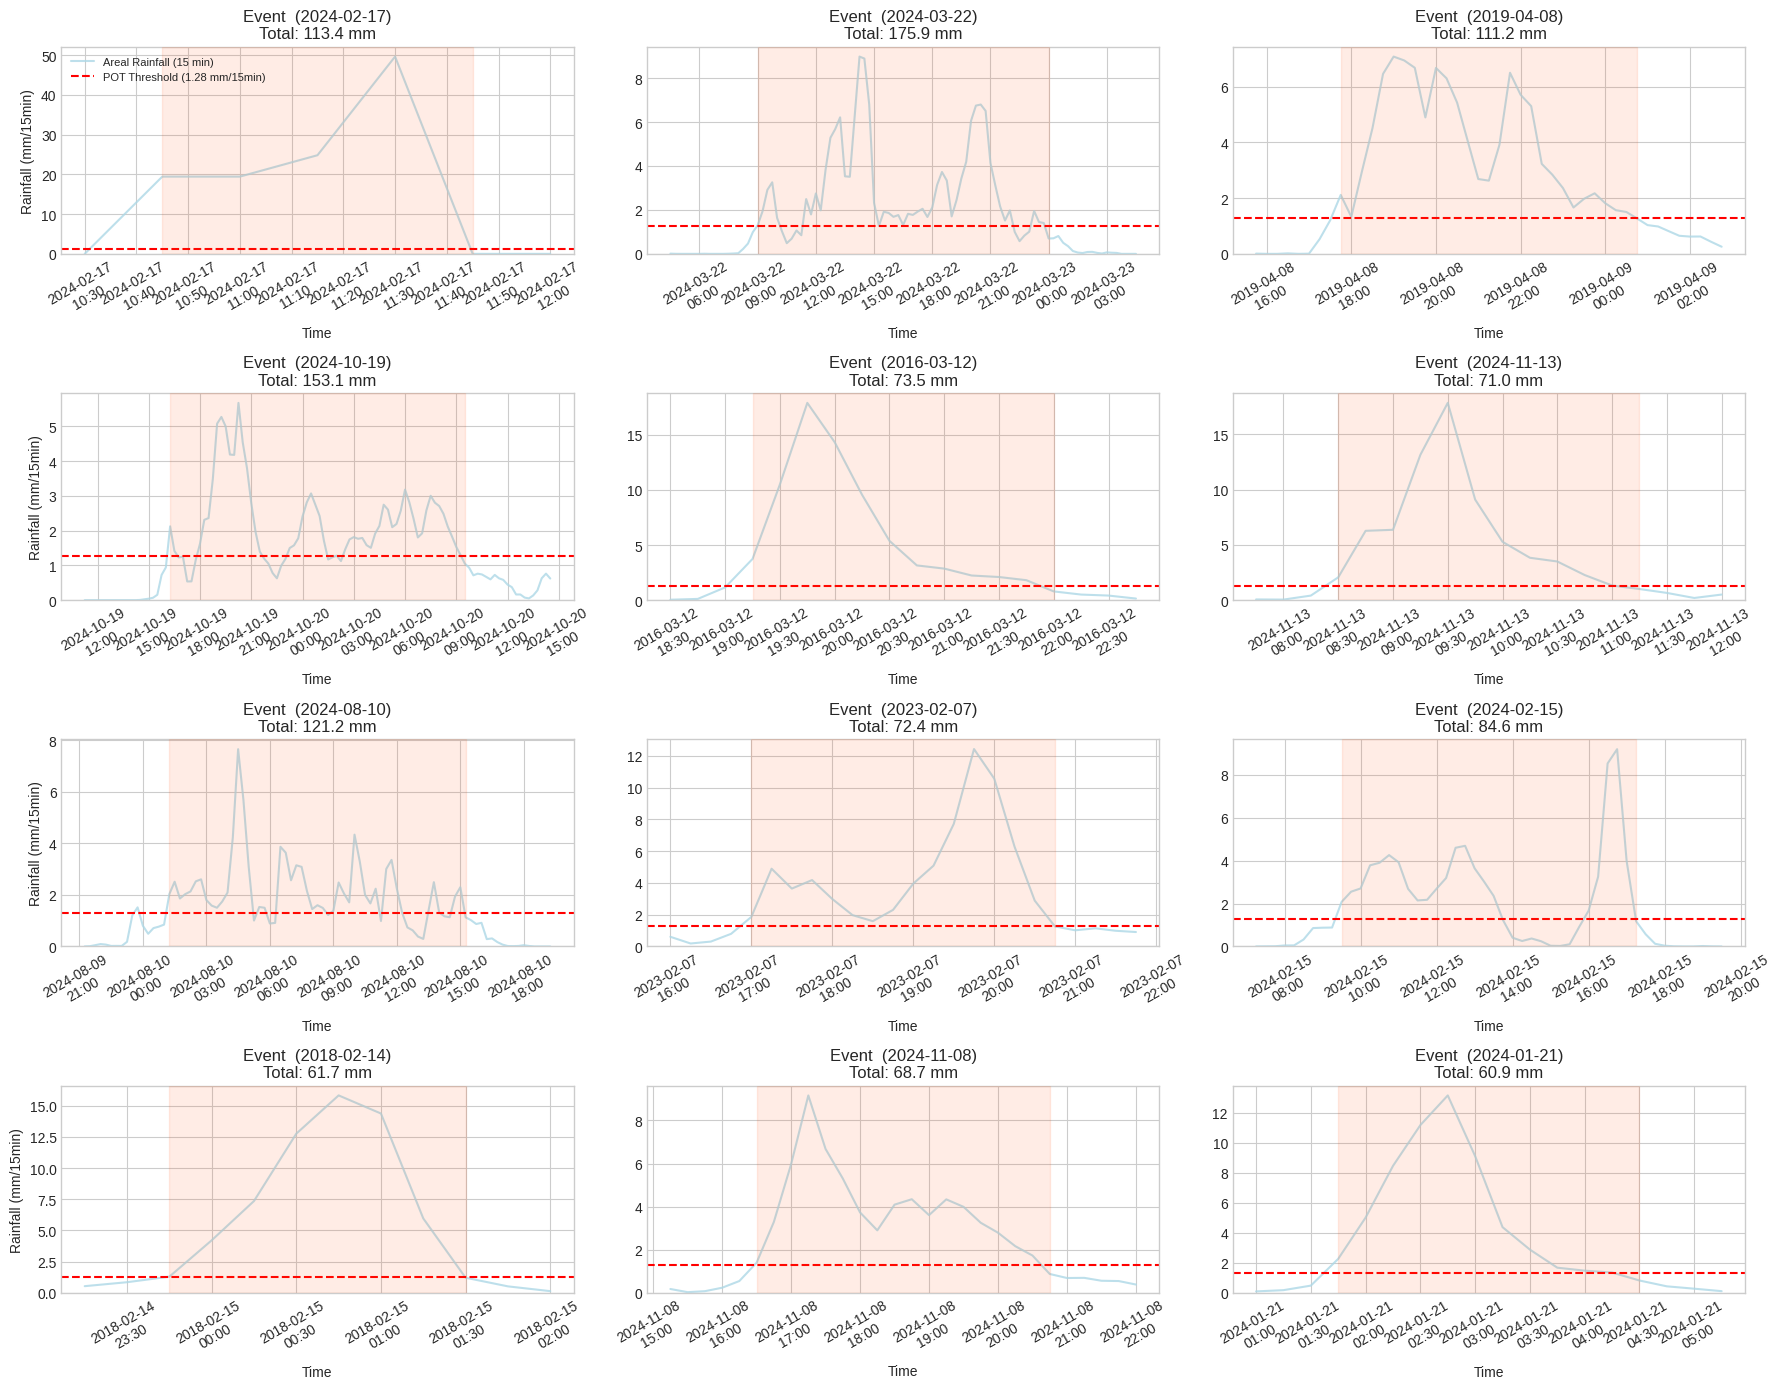

In [ ]:
# Grid of 12 charts: 6 for top rain events, 6 for lowest rain events (with nonzero rainfall)
import matplotlib.pyplot as plt

pad_hours = None
pad_prct = 0.3
n_top_events = 12
n_bottom_events = 0

n_cols = 3
n_rows = 4
n_charts = n_cols * n_rows

# Select top 6 and lowest 6 (nonzero) rain events by total rainfall
if not pot_events_df.empty:
    # Top 6
    top_events = pot_events_df.sort_values(by='magnitude_over_threshold_mm', ascending=False).head(n_top_events)
    # Lowest 6 (nonzero)
    lowest_events = pot_events_df[pot_events_df['total_rainfall_during_exceedance_phase'] > 0].sort_values('total_rainfall_during_exceedance_phase').head(n_bottom_events)
    events_to_plot = pd.concat([top_events, lowest_events], ignore_index=True)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 14)) # , sharey=True
    axes = axes.flatten()
    
    for i, (_, event_row) in enumerate(events_to_plot.iterrows()):
        ax = axes[i]
        event_start = event_row['start_time']
        event_end = event_row['end_time']
        # Plot a window around the event (±1 day)
        event_delta = event_end - event_start
        if pad_hours is not None:
            window_start = event_start - pd.Timedelta(hours=pad_hours)
            window_end = event_end + pd.Timedelta(hours=pad_hours)
        elif pad_prct is not None:
            window_start = event_start - event_delta * pad_prct
            window_end = event_end + event_delta * pad_prct

        plot_data = areal_rainfall_15T_df[
            (areal_rainfall_15T_df['timestamp'] >= window_start) &
            (areal_rainfall_15T_df['timestamp'] <= window_end)
        ]
        ax.plot(plot_data['timestamp'], plot_data['rainfall_mm_15min'],
                label='Areal Rainfall (15 min)', color='lightblue', zorder=1, alpha=0.8)
        ax.axhline(POT_INTENSITY_THRESHOLD, color='red', linestyle='--',
                   label=f'POT Threshold ({POT_INTENSITY_THRESHOLD:.2f} mm/15min)', zorder=2)
        # Highlight overlapping POT events
        for _, pot_row in pot_events_df[
            (pot_events_df['start_time'] < event_end) &
            (pot_events_df['end_time'] > event_start)
        ].iterrows():
            ax.axvspan(pot_row['start_time'], pot_row['end_time'],
                       color=sns.color_palette("autumn")[1], alpha=0.10, zorder=3)
        ax.set_title(f"Event {event_row.get('event_id', '')} ({event_start:%Y-%m-%d})\nTotal: {event_row['total_rainfall_during_exceedance_phase']:.1f} mm")
        ax.set_xlabel('Time')
        if i % n_cols == 0:
            ax.set_ylabel('Rainfall (mm/15min)')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M'))
        ax.tick_params(axis='x', rotation=30)
        ax.set_ylim(bottom=0)
        if i == 0:
            ax.legend(fontsize=8)
    # Hide unused axes if any
    for j in range(i+1, n_charts):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()
else:
    print("Required data for rain events or POT events is missing.")

#### Visualizations of POT Events for Top Continous Rain Events

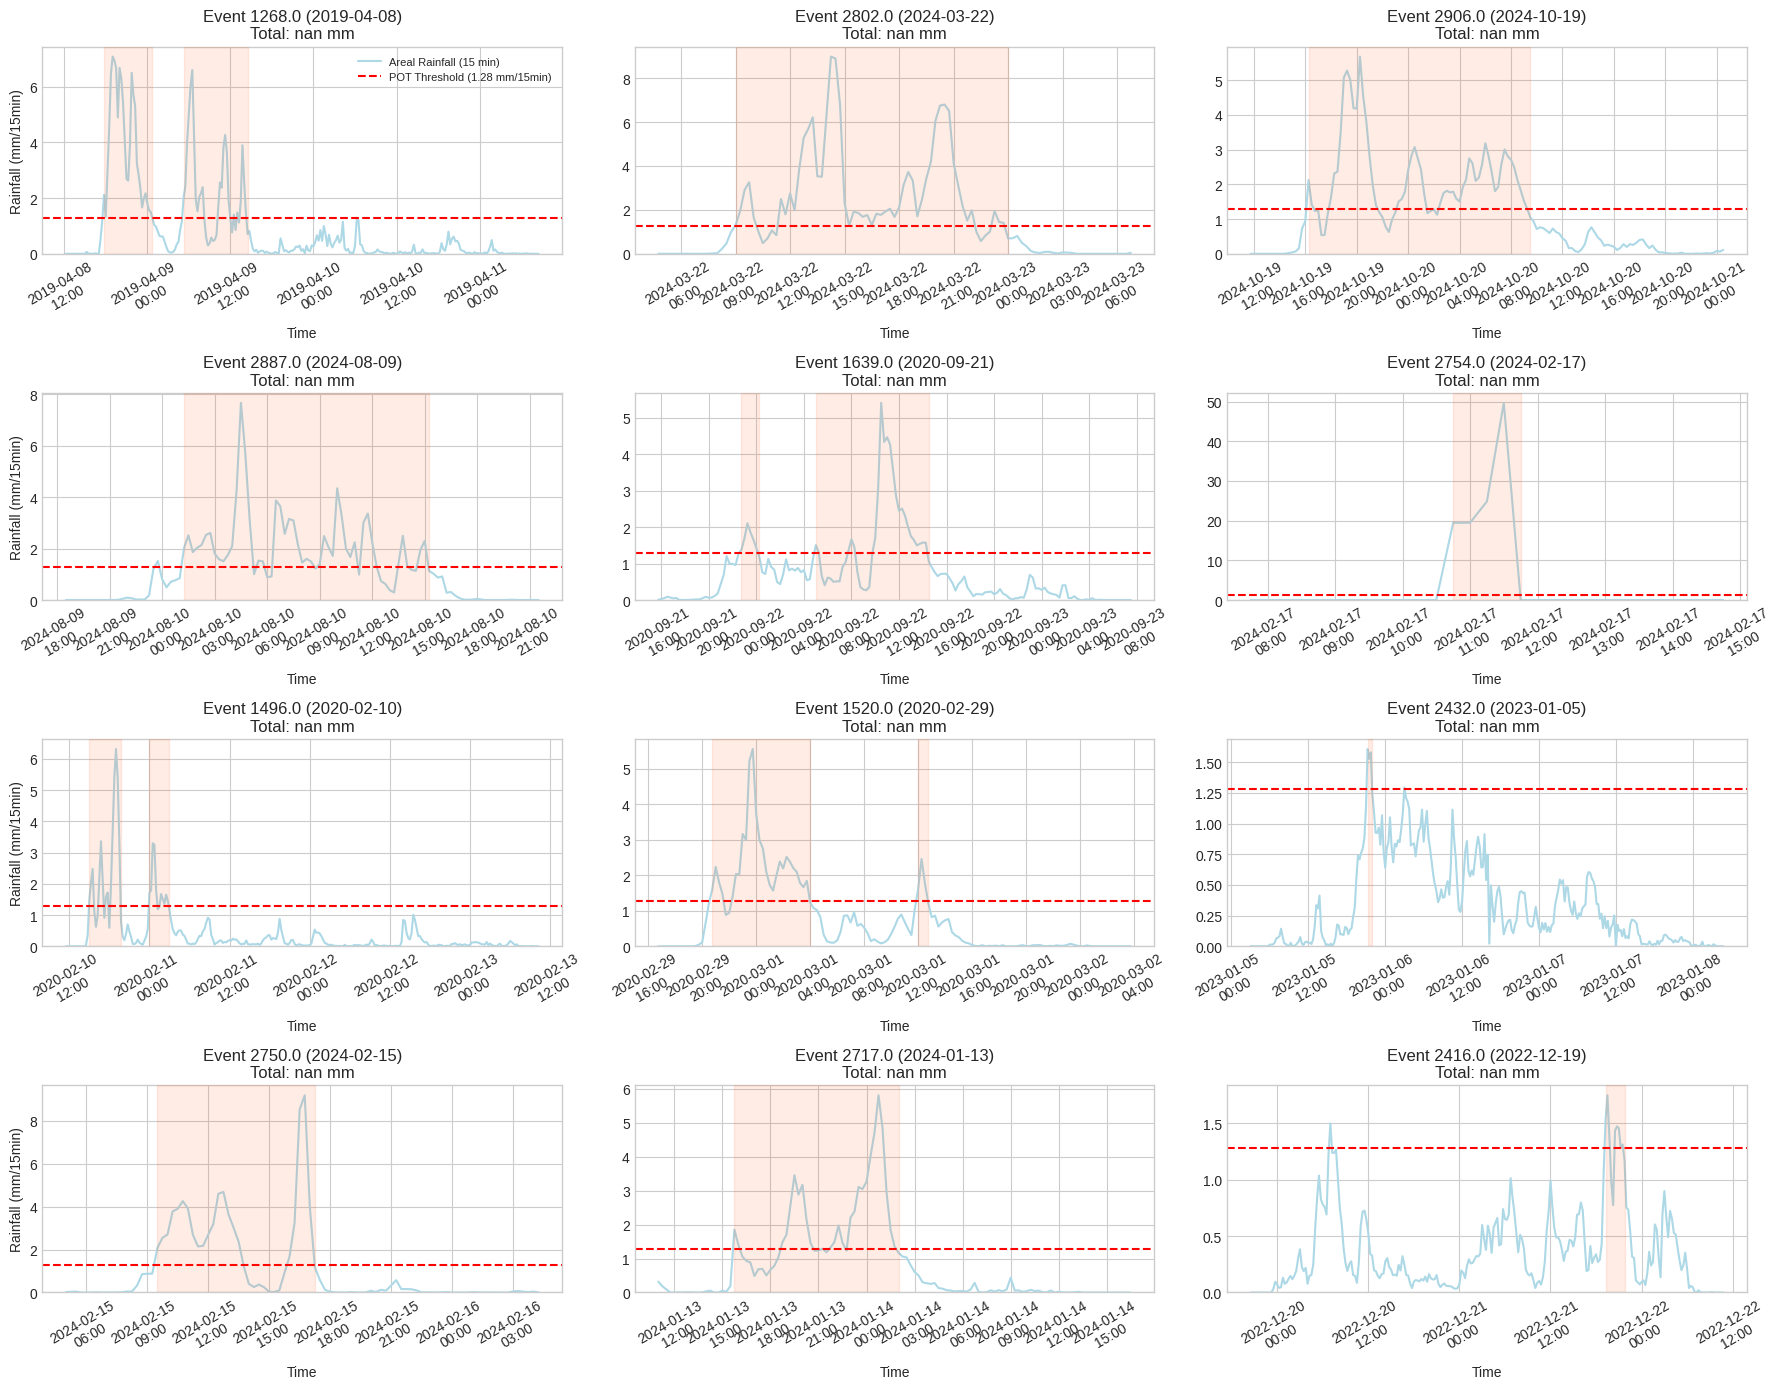

In [ ]:
# Grid of 12 charts: 6 for top rain events, 6 for lowest rain events (with nonzero rainfall)
import matplotlib.pyplot as plt

pad_hours = 3
n_top_events = 12
n_bottom_events = 0

n_cols = 3
n_rows = 4
n_charts = n_cols * n_rows

# Select top 6 and lowest 6 (nonzero) rain events by total rainfall
if not pot_events_df.empty:
    # Top 6
    top_events = rain_events_df.sort_values(by='total_rainfall_mm', ascending=False).head(n_top_events)
    # Lowest 6 (nonzero)
    lowest_events = pot_events_df[pot_events_df['total_rainfall_during_exceedance_phase'] > 0].sort_values('total_rainfall_during_exceedance_phase').head(n_bottom_events)
    events_to_plot = pd.concat([top_events, lowest_events], ignore_index=True)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 14)) # , sharey=True
    axes = axes.flatten()
    
    for i, (_, event_row) in enumerate(events_to_plot.iterrows()):
        ax = axes[i]
        event_start = event_row['start_time']
        event_end = event_row['end_time']
        # Plot a window around the event (±1 day)
        window_start = event_start - pd.Timedelta(hours=pad_hours)
        window_end = event_end + pd.Timedelta(hours=pad_hours)
        plot_data = areal_rainfall_15T_df[
            (areal_rainfall_15T_df['timestamp'] >= window_start) &
            (areal_rainfall_15T_df['timestamp'] <= window_end)
        ]
        ax.plot(plot_data['timestamp'], plot_data['rainfall_mm_15min'],
                label='Areal Rainfall (15 min)', color='lightblue', zorder=1, alpha=1.0)
        ax.axhline(POT_INTENSITY_THRESHOLD, color='red', linestyle='--',
                   label=f'POT Threshold ({POT_INTENSITY_THRESHOLD:.2f} mm/15min)', zorder=2)
        # Highlight overlapping POT events
        for _, pot_row in pot_events_df[
            (pot_events_df['start_time'] < event_end) &
            (pot_events_df['end_time'] > event_start)
        ].iterrows():
            ax.axvspan(pot_row['start_time'], pot_row['end_time'],
                       color=sns.color_palette("autumn")[1], alpha=0.10, zorder=3)
        ax.set_title(f"Event {event_row.get('event_id', '')} ({event_start:%Y-%m-%d})\nTotal: {event_row['total_rainfall_during_exceedance_phase']:.1f} mm")
        ax.set_xlabel('Time')
        if i % n_cols == 0:
            ax.set_ylabel('Rainfall (mm/15min)')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M'))
        ax.tick_params(axis='x', rotation=30)
        ax.set_ylim(bottom=0)
        if i == 0:
            ax.legend(fontsize=8)
    # Hide unused axes if any
    for j in range(i+1, n_charts):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()
else:
    print("Required data for rain events or POT events is missing.")

### 2.5. Save Outputs from Advanced Event Analysis (Part 2)

In [ ]:
# Save daily rainfall data
daily_rainfall_output_path = os.path.join(OUTPUT_DATA_DIRECTORY, DAILY_RAINFALL_FILENAME)
try:
    daily_rainfall_df.to_csv(daily_rainfall_output_path, index=False)
    print(f"\nDaily areal rainfall data saved to: {daily_rainfall_output_path}")
except Exception as e:
    print(f"Error saving daily rainfall data: {e}")

# Save rain events data
if not rain_events_df.empty:
    rain_events_output_path = os.path.join(OUTPUT_DATA_DIRECTORY, RAIN_EVENTS_FILENAME)
    try:
        rain_events_df.to_csv(rain_events_output_path, index=False)
        print(f"Rain events data saved to: {rain_events_output_path}")
    except Exception as e:
        print(f"Error saving rain events data: {e}")
else:
    print("Rain events DataFrame is empty, not saving.")

# Save POT events data
if not pot_events_df.empty:
    pot_events_output_path = os.path.join(OUTPUT_DATA_DIRECTORY, POT_EVENTS_FILENAME)
    try:
        pot_events_df.to_csv(pot_events_output_path, index=False)
        print(f"POT events data saved to: {pot_events_output_path}")
    except Exception as e:
        print(f"Error saving POT events data: {e}")
else:
    print("POT events DataFrame is empty, not saving.")

print("\n--- End of Part 2: Advanced Rainfall Event Analysis ---")


Daily areal rainfall data saved to: ../../../../data/meteorologia/processed/thiessen_analysis/daily_areal_rainfall_rio.csv
Rain events data saved to: ../../../../data/meteorologia/processed/thiessen_analysis/rain_events_rio.csv
POT events data saved to: ../../../../data/meteorologia/processed/thiessen_analysis/pot_events_rio.csv

--- End of Part 2: Advanced Rainfall Event Analysis ---


## Part 3: Evaluation and Comparison of Rainfall Event Identification Methods

This part provides an in-depth evaluation of the three methodologies used for identifying significant rainfall periods: Daily Rainfall Aggregation, Continuous Rainfall Period Identification, and Peak Over Threshold (POT) Analysis. We examine the characteristics of events captured by each method and discuss their strengths, limitations, and interrelations.

### 3.1. Recap of Identified Events

A summary of the number and overall characteristics of events identified by each method.

In [ ]:
print("--- Summary of Identified Events (from Part 2) ---")

print(f"\n1. Daily Rainfall Aggregation:")
if 'daily_rainfall_df' in locals() and not daily_rainfall_df.empty:
    print(f"   Total days in dataset: {len(daily_rainfall_df)}")
    print(f"   Number of rainy days (> {MIN_RAIN_FOR_RAINY_DAY} mm): {len(rainy_days_df)}")
    print(f"   Percentage of rainy days: {(len(rainy_days_df) / len(daily_rainfall_df) * 100):.2f}%")
    if not rainy_days_df.empty:
      print(f"   Mean daily rainfall on rainy days: {rainy_days_df['total_daily_rainfall_mm'].mean():.2f} mm")
    print(f"   Max daily rainfall recorded: {daily_rainfall_df['total_daily_rainfall_mm'].max():.2f} mm")
    if 'most_rainy_days' in locals() and not most_rainy_days.empty: display(most_rainy_days.head(3))
else:
    print("   Daily rainfall data not available.")


print(f"\n2. Continuous Rainfall Period Identification (Rain Events):")
if 'rain_events_df' in locals() and not rain_events_df.empty:
    print(f"   Total continuous rain events identified: {len(rain_events_df)}")
    print(f"   Mean event duration: {rain_events_df['duration'].mean()}")
    print(f"   Mean total rainfall per event: {rain_events_df['total_rainfall_mm'].mean():.2f} mm")
    print(f"   Mean peak 15-min intensity per event: {rain_events_df['peak_15min_intensity_mm'].mean():.2f} mm/15min")
    print(f"   Max total rainfall in an event: {rain_events_df['total_rainfall_mm'].max():.2f} mm")
    if 'most_intense_events' in locals() and not most_intense_events.empty: display(most_intense_events[['start_time', 'duration', 'total_rainfall_mm', 'peak_15min_intensity_mm']].head(3))
else:
    print("   Continuous rain events data not available.")


print(f"\n3. Peak Over Threshold (POT) Event Analysis:")
if 'pot_events_df' in locals() and not pot_events_df.empty:
    print(f"   POT Intensity Threshold used: {POT_INTENSITY_THRESHOLD:.2f} mm/15min")
    print(f"   Total POT events identified: {len(pot_events_df)}")
    print(f"   Mean duration of exceedance phase: {pot_events_df['duration_exceedance_phase'].mean()}")
    print(f"   Mean total rainfall during exceedance phase: {pot_events_df['total_rainfall_during_exceedance_phase'].mean():.2f} mm")
    print(f"   Mean magnitude over threshold: {pot_events_df['magnitude_over_threshold_mm'].mean():.2f} mm")
    print(f"   Max peak 15-min intensity during POT event: {pot_events_df['peak_15min_intensity_during_exceedance_phase'].max():.2f} mm/15min")
    if 'most_significant_pot_events' in locals() and not most_significant_pot_events.empty: display(most_significant_pot_events[['start_time', 'duration_exceedance_phase', 'total_rainfall_during_exceedance_phase', 'magnitude_over_threshold_mm']].head(3))
else:
    print("   POT events data not available.")

--- Summary of Identified Events (from Part 2) ---

1. Daily Rainfall Aggregation:
   Total days in dataset: 3639
   Number of rainy days (> 0.01 mm): 1860
   Percentage of rainy days: 51.11%
   Mean daily rainfall on rainy days: 7.32 mm
   Max daily rainfall recorded: 177.71 mm


,timestamp,total_daily_rainfall_mm
3368,2024-03-22,177.706259
3509,2024-08-10,129.696627
3334,2024-02-17,113.408959



2. Continuous Rainfall Period Identification (Rain Events):
   Total continuous rain events identified: 2966
   Mean event duration: 0 days 04:05:38.031018206
   Mean total rainfall per event: 4.58 mm
   Mean peak 15-min intensity per event: 0.66 mm/15min
   Max total rainfall in an event: 233.79 mm


,start_time,duration,total_rainfall_mm,peak_15min_intensity_mm
1267,2019-04-08 15:15:00,2 days 14:15:00,233.785435,7.074515
2801,2024-03-22 07:45:00,0 days 20:00:00,181.298409,8.979934
2905,2024-10-19 14:45:00,1 days 06:45:00,171.301771,5.679691



3. Peak Over Threshold (POT) Event Analysis:
   POT Intensity Threshold used: 1.28 mm/15min
   Total POT events identified: 303
   Mean duration of exceedance phase: 0 days 01:54:39.207920792
   Mean total rainfall during exceedance phase: 19.23 mm
   Mean magnitude over threshold: 10.16 mm
   Max peak 15-min intensity during POT event: 49.67 mm/15min


,start_time,duration_exceedance_phase,total_rainfall_during_exceedance_phase,magnitude_over_threshold_mm
269,2024-02-17 10:45:00,0 days 01:00:00,113.402363,108.268875
274,2024-03-22 09:00:00,0 days 15:00:00,175.878453,102.899443
123,2019-04-08 17:45:00,0 days 07:00:00,111.201546,75.267127


### 3.2. Detailed Evaluation of Daily Rainfall Aggregation

This method provides a calendar-based view of rainfall.

**Characteristics & Distribution:**
The `most_rainy_days` DataFrame (top 10 days by total rainfall) highlights days with exceptionally high cumulative rainfall. The distribution of daily rainfall amounts on rainy days is typically right-skewed.

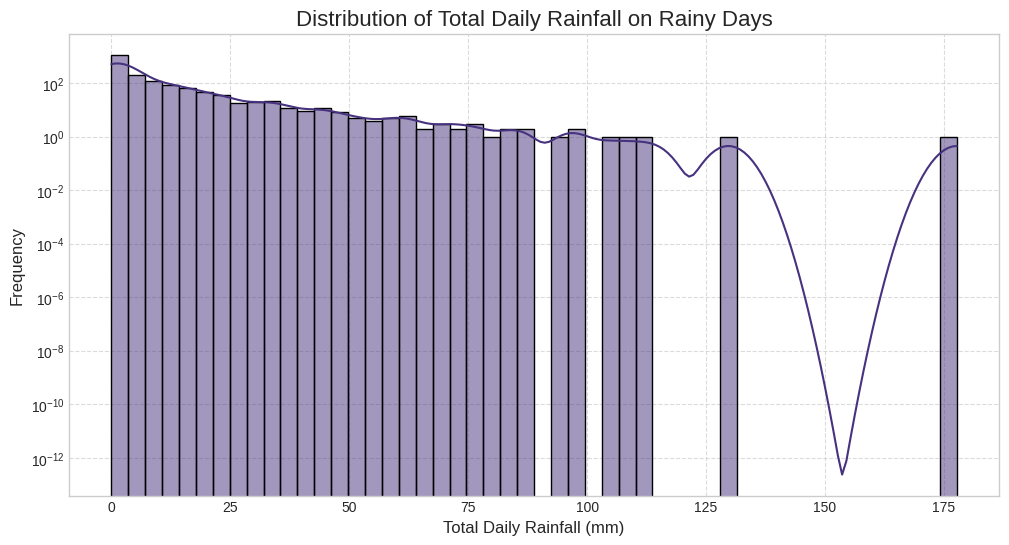

Descriptive statistics for daily rainfall on rainy days:


count    1860.000000
mean        7.322872
std        14.211986
min         0.010315
50%         1.750071
75%         7.848912
90%        20.522712
95%        33.606540
99%        70.756788
max       177.706259
Name: total_daily_rainfall_mm, dtype: float64

In [ ]:
if 'rainy_days_df' in locals() and not rainy_days_df.empty:
    plt.figure(figsize=(12, 6))
    sns.histplot(data=rainy_days_df, x='total_daily_rainfall_mm', bins=50, kde=True, color=sns.color_palette("viridis")[0])
    plt.title('Distribution of Total Daily Rainfall on Rainy Days', fontsize=16)
    plt.xlabel('Total Daily Rainfall (mm)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    print("Descriptive statistics for daily rainfall on rainy days:")
    display(rainy_days_df['total_daily_rainfall_mm'].describe(percentiles=[.5, .75, .90, .95, .99]))
else:
    print("Rainy days data not available for distribution plot.")

**Evaluation:**
*   **Strengths:**
    *   Simplicity and intuitiveness.
    *   Standard for climatological summaries.
    *   Broad indication of impactful weather days.
*   **Weaknesses:**
    *   Loss of intra-day temporal detail (intensity, duration of bursts).
    *   Arbitrary midnight cutoff can split meteorological events.
    *   Limited for detailed hydrological process understanding.

### 3.3. Detailed Evaluation of Continuous Rainfall Period Identification

This method groups consecutive rainy intervals into hydrologically relevant events.

**Characteristics & Distributions:**
The `most_intense_events` DataFrame (top 10 continuous events by total rainfall) showcases events with large accumulated rainfall, characterized by start/end times, duration, total volume, and peak intensity. Distributions of event duration, total rainfall, and peak intensity reveal typical event structures.

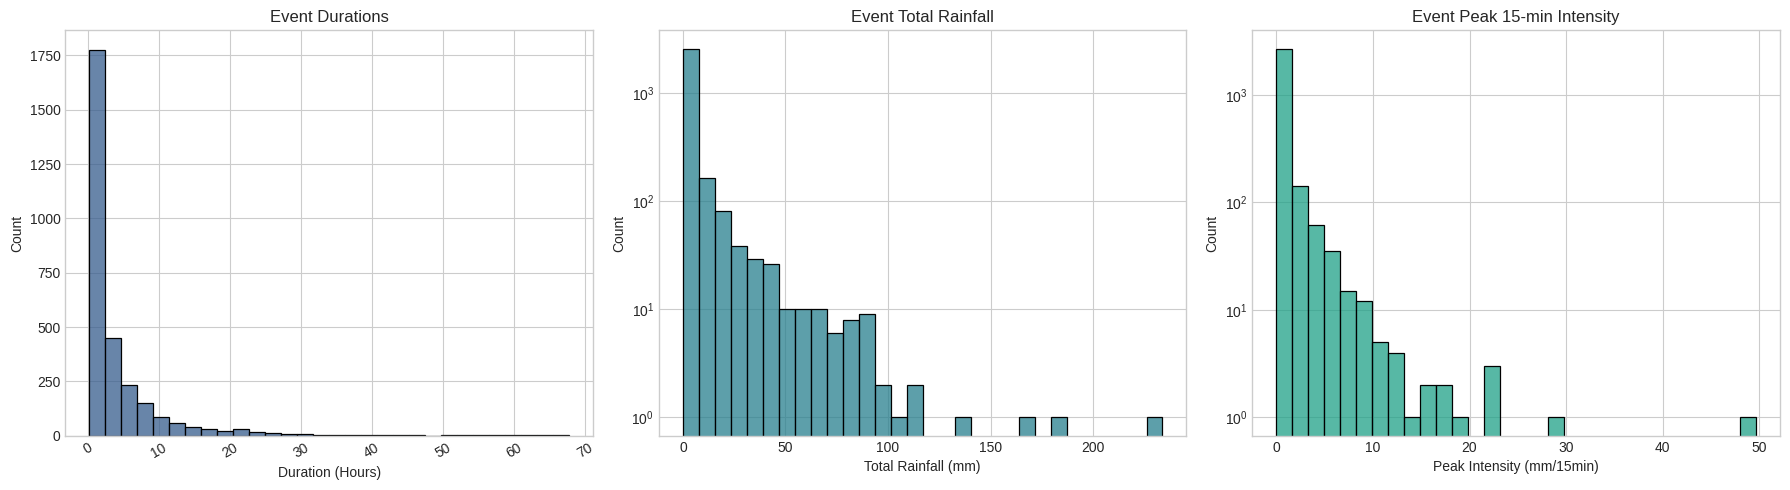


Descriptive Statistics for Continuous Rain Event Properties:


,duration,total_rainfall_mm,peak_15min_intensity_mm,avg_intensity_mm_hr
count,2966,2966.000000,2966.000000,2966.000000
mean,0 days 04:05:38.031018206,4.577506,0.659293,0.641393
std,0 days 06:57:14.119382455,13.772621,1.977855,3.545295
min,0 days 00:15:00,0.010075,0.010075,0.019520
50%,0 days 01:30:00,0.220932,0.081584,0.144429
75%,0 days 04:30:00,2.238156,0.454560,0.500158
90%,0 days 10:30:00,11.977403,1.605920,1.347895
95%,0 days 16:56:15,24.235199,3.229835,2.345439
99%,1 days 10:05:59.999999999,72.091597,8.767917,5.079646
max,2 days 19:45:00,233.785435,49.669459,113.402363


In [ ]:
if 'rain_events_df' in locals() and not rain_events_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Duration
    sns.histplot(rain_events_df['duration'].dt.total_seconds() / 3600, ax=axes[0], bins=30, color=sns.color_palette("viridis")[1])
    axes[0].set_title('Event Durations')
    axes[0].set_xlabel('Duration (Hours)')
    axes[0].tick_params(axis='x', rotation=30)

    # Total rainfall
    sns.histplot(rain_events_df['total_rainfall_mm'], ax=axes[1], bins=30, color=sns.color_palette("viridis")[2])
    axes[1].set_title('Event Total Rainfall')
    axes[1].set_xlabel('Total Rainfall (mm)')
    axes[1].set_yscale('log')

    # Peak 15-min intensity
    sns.histplot(rain_events_df['peak_15min_intensity_mm'], ax=axes[2], bins=30, color=sns.color_palette("viridis")[3])
    axes[2].set_title('Event Peak 15-min Intensity')
    axes[2].set_xlabel('Peak Intensity (mm/15min)')
    axes[2].set_yscale('log')

    plt.tight_layout()
    plt.show()

    print("\nDescriptive Statistics for Continuous Rain Event Properties:")
    display(rain_events_df[['duration', 'total_rainfall_mm', 'peak_15min_intensity_mm', 'avg_intensity_mm_hr']].describe(percentiles=[.5, .75, .90, .95, .99]))
else:
    print("Continuous rain events data not available for distribution plots.")

**Evaluation:**
*   **Strengths:**
    *   Hydrologically relevant event definition.
    *   Captures key metrics (duration, volume, intensities) for impact assessment.
    *   Parameters (`rain_threshold`, `min_dry_spell_duration`) allow for tailored definitions.
*   **Weaknesses:**
    *   Sensitive to parameter choices.
    *   More complex algorithm than daily aggregation.
    *   May group periods of varying intensity; POT analysis can complement this.

### 3.4. Detailed Evaluation of Peak Over Threshold (POT) Event Analysis

This method targets periods of high-intensity rainfall.

**Characteristics & Distributions:**
The `most_significant_pot_events` DataFrame (top 10 POT events by magnitude over threshold) highlights periods where rainfall intensity markedly exceeded the defined threshold. Key metrics include duration of the exceedance phase, total rain during this phase, peak intensity, and magnitude over threshold.

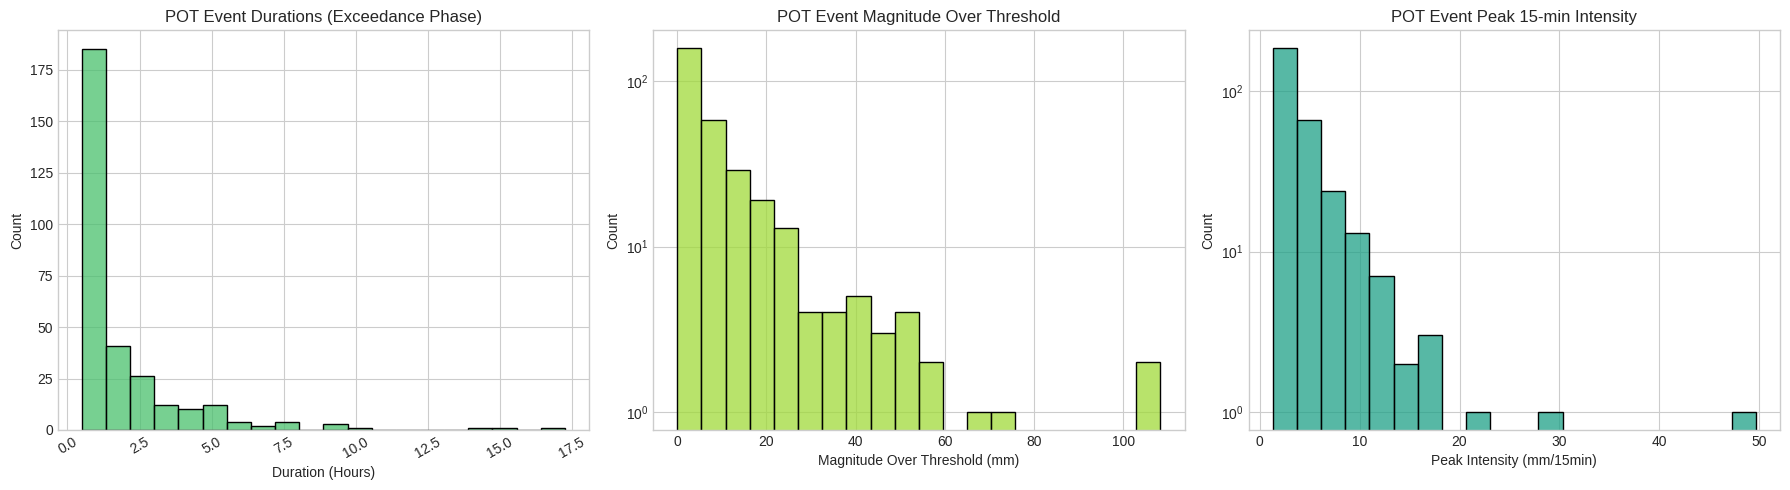


Descriptive Statistics for POT Event Properties:


,duration_exceedance_phase,total_rainfall_during_exceedance_phase,peak_15min_intensity_during_exceedance_phase,magnitude_over_threshold_mm
count,303,303.000000,303.000000,303.000000
mean,0 days 01:54:39.207920792,19.232635,4.375305,10.155420
std,0 days 02:15:07.199606722,22.907575,4.238475,14.769601
min,0 days 00:30:00,2.596352,1.302486,0.029608
50%,0 days 01:00:00,10.896304,3.223266,4.725506
75%,0 days 02:15:00,23.071129,5.173527,12.679904
90%,0 days 04:30:00,44.509746,7.624205,24.767580
95%,0 days 05:45:00,64.441983,10.789248,41.206556
99%,0 days 10:14:06,113.358347,17.889481,68.204745
max,0 days 17:15:00,175.878453,49.669459,108.268875


In [ ]:
if 'pot_events_df' in locals() and not pot_events_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Duration of Exceedance Phase
    sns.histplot(pot_events_df['duration_exceedance_phase'].dt.total_seconds() / 3600, ax=axes[0], bins=20, color=sns.color_palette("viridis")[4])
    axes[0].set_title('POT Event Durations (Exceedance Phase)')
    axes[0].set_xlabel('Duration (Hours)')
    axes[0].tick_params(axis='x', rotation=30)

    # Magnitude over threshold
    sns.histplot(pot_events_df['magnitude_over_threshold_mm'], ax=axes[1], bins=20, color=sns.color_palette("viridis")[5])
    axes[1].set_title('POT Event Magnitude Over Threshold')
    axes[1].set_xlabel('Magnitude Over Threshold (mm)')
    axes[1].set_yscale('log')

    # Peak 15-min intensity during POT event
    sns.histplot(pot_events_df['peak_15min_intensity_during_exceedance_phase'], ax=axes[2], bins=20, color=sns.color_palette("viridis_r")[2]) # Using a reversed map variant
    axes[2].set_title('POT Event Peak 15-min Intensity')
    axes[2].set_xlabel('Peak Intensity (mm/15min)')
    axes[2].set_yscale('log')

    plt.tight_layout()
    plt.show()

    print("\nDescriptive Statistics for POT Event Properties:")
    display(pot_events_df[['duration_exceedance_phase', 'total_rainfall_during_exceedance_phase',
                        'peak_15min_intensity_during_exceedance_phase', 'magnitude_over_threshold_mm']].describe(percentiles=[.5, .75, .90, .95, .99]))
else:
    print("POT events data not available for distribution plots.")

**Evaluation:**
*   **Strengths:**
    *   Focuses on extreme rainfall rates critical for acute hazards.
    *   Statistically grounded in Extreme Value Theory.
    *   Provides detailed information on high-intensity periods.
*   **Weaknesses:**
    *   Highly dependent on `pot_threshold` selection.
    *   Ignores lower intensity rain, even if prolonged and high-volume.
    *   Event definition (clustering parameters) can influence results.

### 3.5. Comparative Analysis: Overlaps Between Event Types

Investigating how events identified by one method relate to those from others.

#### 3.5.1. Overlap: Top Daily Events vs. Continuous Rain Events

In [ ]:
if 'most_rainy_days' in locals() and not most_rainy_days.empty and \
   'rain_events_df' in locals() and not rain_events_df.empty and \
   'areal_rainfall_15T_df' in locals() and not areal_rainfall_15T_df.empty:

    print(f"\n--- Overlap: Top {len(most_rainy_days)} Daily Rain Events vs. Continuous Rain Events ---")
    comparison_data_dvsc = []
    for idx, daily_event in most_rainy_days.iterrows():
        day_start = daily_event['timestamp']
        day_end = day_start + pd.Timedelta(days=1)

        overlapping_continuous = rain_events_df[
            (rain_events_df['start_time'] < day_end) &
            (rain_events_df['end_time'] > day_start)
        ].copy()

        num_cont = len(overlapping_continuous)
        total_rain_cont_on_day = 0
        largest_cont_id = None
        largest_cont_rain = 0

        if num_cont > 0:
            for _, cont_ev in overlapping_continuous.iterrows():
                overlap_s = max(day_start, cont_ev['start_time'])
                overlap_e = min(day_end, cont_ev['end_time'])
                if overlap_s < overlap_e:
                    rain_in_overlap_series = areal_rainfall_15T_df[
                        (areal_rainfall_15T_df['timestamp'] >= overlap_s) &
                        (areal_rainfall_15T_df['timestamp'] < overlap_e)
                    ]['rainfall_mm_15min']
                    if not rain_in_overlap_series.empty:
                         total_rain_cont_on_day += rain_in_overlap_series.sum()

            largest_cont_rain = overlapping_continuous['total_rainfall_mm'].max()
            if pd.notna(largest_cont_rain): # Ensure max is not NaN if df was empty after filtering
                largest_cont_id = overlapping_continuous.loc[overlapping_continuous['total_rainfall_mm'].idxmax()]['event_id']


        comparison_data_dvsc.append({
            'Rainy Day Date': day_start.strftime('%Y-%m-%d'),
            'Daily Total (mm)': daily_event['total_daily_rainfall_mm'],
            'Num Overlapping Cont. Events': num_cont,
            'Total Rain from Cont. Events on Day (mm)': total_rain_cont_on_day,
            'Largest Cont. Event ID on Day': largest_cont_id,
            'Largest Cont. Event Total Rain (mm)': largest_cont_rain
        })
    daily_vs_continuous_df = pd.DataFrame(comparison_data_dvsc)
    display(daily_vs_continuous_df)
else:
    print("Skipping Daily vs Continuous comparison: one or more required DataFrames are missing or empty.")


--- Overlap: Top 10 Daily Rain Events vs. Continuous Rain Events ---


,Rainy Day Date,Daily Total (mm),Num Overlapping Cont. Events,Total Rain from Cont. Events on Day (mm),Largest Cont. Event ID on Day,Largest Cont. Event Total Rain (mm)
0,2024-03-22,177.706259,3,177.680848,2802,181.298409
1,2024-08-10,129.696627,2,129.681972,2887,132.860516
2,2024-02-17,113.408959,1,113.402363,2754,113.402363
3,2019-04-08,108.144412,1,108.144412,1268,233.785435
4,2019-04-09,103.245856,1,103.245856,1268,233.785435
5,2024-02-15,97.449889,2,97.433072,2750,91.403778
6,2024-10-20,96.768693,2,96.751849,2906,171.301771
7,2020-09-22,95.541436,1,95.541436,1639,113.902983
8,2024-11-13,85.594215,2,85.585808,2930,83.093944
9,2023-02-07,85.464784,2,85.461617,2471,85.591061


#### 3.5.2. Overlap: Top Continuous Rain Events vs. POT Events

In [ ]:
MAX_EVENTS = 8

if 'most_intense_events' in locals() and not most_intense_events.empty and \
   'pot_events_df' in locals() and not pot_events_df.empty:

    print(f"\n--- Overlap: Top {len(most_intense_events)} Continuous Rain Events vs. POT Events ---")
    comparison_data_cvsp = []
    for idx, cont_event in most_intense_events.iterrows():
        event_start = cont_event['start_time']
        event_end = cont_event['end_time']

        overlapping_pot = pot_events_df[
            (pot_events_df['start_time'] < event_end) &
            (pot_events_df['end_time'] > event_start)
        ]

        num_pot = len(overlapping_pot)
        total_pot_mag = 0
        max_pot_peak = 0
        if num_pot > 0:
            total_pot_mag = overlapping_pot['magnitude_over_threshold_mm'].sum()
            max_pot_peak = overlapping_pot['peak_15min_intensity_during_exceedance_phase'].max()

        comparison_data_cvsp.append({
            'Cont. Event ID': cont_event['event_id'],
            'Cont. Event Start': cont_event['start_time'].strftime('%Y-%m-%d %H:%M'),
            'Cont. Event Total (mm)': cont_event['total_rainfall_mm'],
            'Cont. Event Peak (mm/15m)': cont_event['peak_15min_intensity_mm'],
            'Num Overlapping POT Events': num_pot,
            'Total POT Magnitude in Cont. Event (mm)': total_pot_mag,
            'Max POT Peak in Cont. Event (mm/15m)': max_pot_peak
        })
    continuous_vs_pot_df = pd.DataFrame(comparison_data_cvsp)
    display(continuous_vs_pot_df)

    # Plotting an example: Top continuous event with its POT events
    continuous_vs_pot_df = continuous_vs_pot_df[continuous_vs_pot_df['Num Overlapping POT Events'] > 0]
    if not continuous_vs_pot_df.empty and continuous_vs_pot_df.iloc[0]['Num Overlapping POT Events'] > 0:
        # top_cont_event_detail = most_intense_events.iloc[0]
        for i in range(MAX_EVENTS):
            top_cont_event_detail = most_intense_events.iloc[i]
            fig, ax = plt.subplots(figsize=(15, 7))
            event_rain_data = areal_rainfall_15T_df[
                (areal_rainfall_15T_df['timestamp'] >= top_cont_event_detail['start_time']) &
                (areal_rainfall_15T_df['timestamp'] < top_cont_event_detail['end_time'])
            ]
            ax.bar(event_rain_data['timestamp'], event_rain_data['rainfall_mm_15min'],
                width=pd.Timedelta(minutes=15)/pd.Timedelta(days=1), color='lightblue', label='15-min Rainfall')
            ax.axhline(POT_INTENSITY_THRESHOLD, color='red', linestyle='--', label=f'POT Threshold ({POT_INTENSITY_THRESHOLD:.2f} mm/15min)')

            overlapping_pots_for_plot = pot_events_df[
                (pot_events_df['start_time'] < top_cont_event_detail['end_time']) &
                (pot_events_df['end_time'] > top_cont_event_detail['start_time'])
            ]
            for i, (_, pot_row) in enumerate(overlapping_pots_for_plot.iterrows()):
                ax.axvspan(pot_row['start_time'], pot_row['end_time'],
                        color=sns.color_palette("autumn")[2], alpha=0.4,
                        label=f"POT Event {pot_row['pot_event_id']}" if i == 0 else None)

            ax.set_title(f"Top Continuous Rain Event (ID {top_cont_event_detail['event_id']}) with Overlapping POT Events", fontsize=16)
            ax.set_xlabel('Timestamp', fontsize=12); ax.set_ylabel('Rainfall (mm/15min)', fontsize=12)
            ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
            plt.xticks(rotation=45); plt.tight_layout(); plt.show()
else:
    print("Skipping Continuous vs POT comparison: one or more required DataFrames are missing or empty.")

Skipping Continuous vs POT comparison: one or more required DataFrames are missing or empty.


#### 3.5.3. Overlap: Top Daily Events vs. POT Events

In [ ]:
if 'most_rainy_days' in locals() and not most_rainy_days.empty and \
   'pot_events_df' in locals() and not pot_events_df.empty:

    print(f"\n--- Overlap: Top {len(most_rainy_days)} Daily Rain Events vs. POT Events ---")
    comparison_data_dvsp = []
    for idx, daily_event in most_rainy_days.iterrows():
        day_start = daily_event['timestamp']
        day_end = day_start + pd.Timedelta(days=1)

        overlapping_pot_daily = pot_events_df[
            (pot_events_df['start_time'] < day_end) &
            (pot_events_df['end_time'] > day_start)
        ]
        num_pot_on_day = len(overlapping_pot_daily)
        total_pot_mag_on_day = 0
        max_pot_peak_on_day = 0
        if num_pot_on_day > 0:
            total_pot_mag_on_day = overlapping_pot_daily['magnitude_over_threshold_mm'].sum()
            max_pot_peak_on_day = overlapping_pot_daily['peak_15min_intensity_during_exceedance_phase'].max()

        comparison_data_dvsp.append({
            'Rainy Day Date': day_start.strftime('%Y-%m-%d'),
            'Daily Total (mm)': daily_event['total_daily_rainfall_mm'],
            'Num POT Events on Day': num_pot_on_day,
            'Total POT Magnitude on Day (mm)': total_pot_mag_on_day,
            'Max POT Peak on Day (mm/15m)': max_pot_peak_on_day
        })
    daily_vs_pot_df = pd.DataFrame(comparison_data_dvsp)
    display(daily_vs_pot_df)
else:
    print("Skipping Daily vs POT comparison: one or more required DataFrames are missing or empty.")


--- Overlap: Top 10 Daily Rain Events vs. POT Events ---


,Rainy Day Date,Daily Total (mm),Num POT Events on Day,Total POT Magnitude on Day (mm),Max POT Peak on Day (mm/15m)
0,2024-03-22,177.706259,1,102.899443,8.979934
1,2024-08-10,129.696627,1,54.031798,7.661518
2,2024-02-17,113.408959,1,108.268875,49.669459
3,2019-04-08,108.144412,1,75.267127,7.074515
4,2019-04-09,103.245856,2,116.437067,7.074515
5,2024-02-15,97.449889,2,72.561926,9.195042
6,2024-10-20,96.768693,1,68.384223,5.679691
7,2020-09-22,95.541436,2,28.736569,5.406913
8,2024-11-13,85.594215,1,56.886725,17.848911
9,2023-02-07,85.464784,1,53.133324,12.434126


### 3.6. Temporal Coincidence of Top Events from Different Methods
A timeline plot to visualize if the "top" events identified by each method tend to occur at similar times.

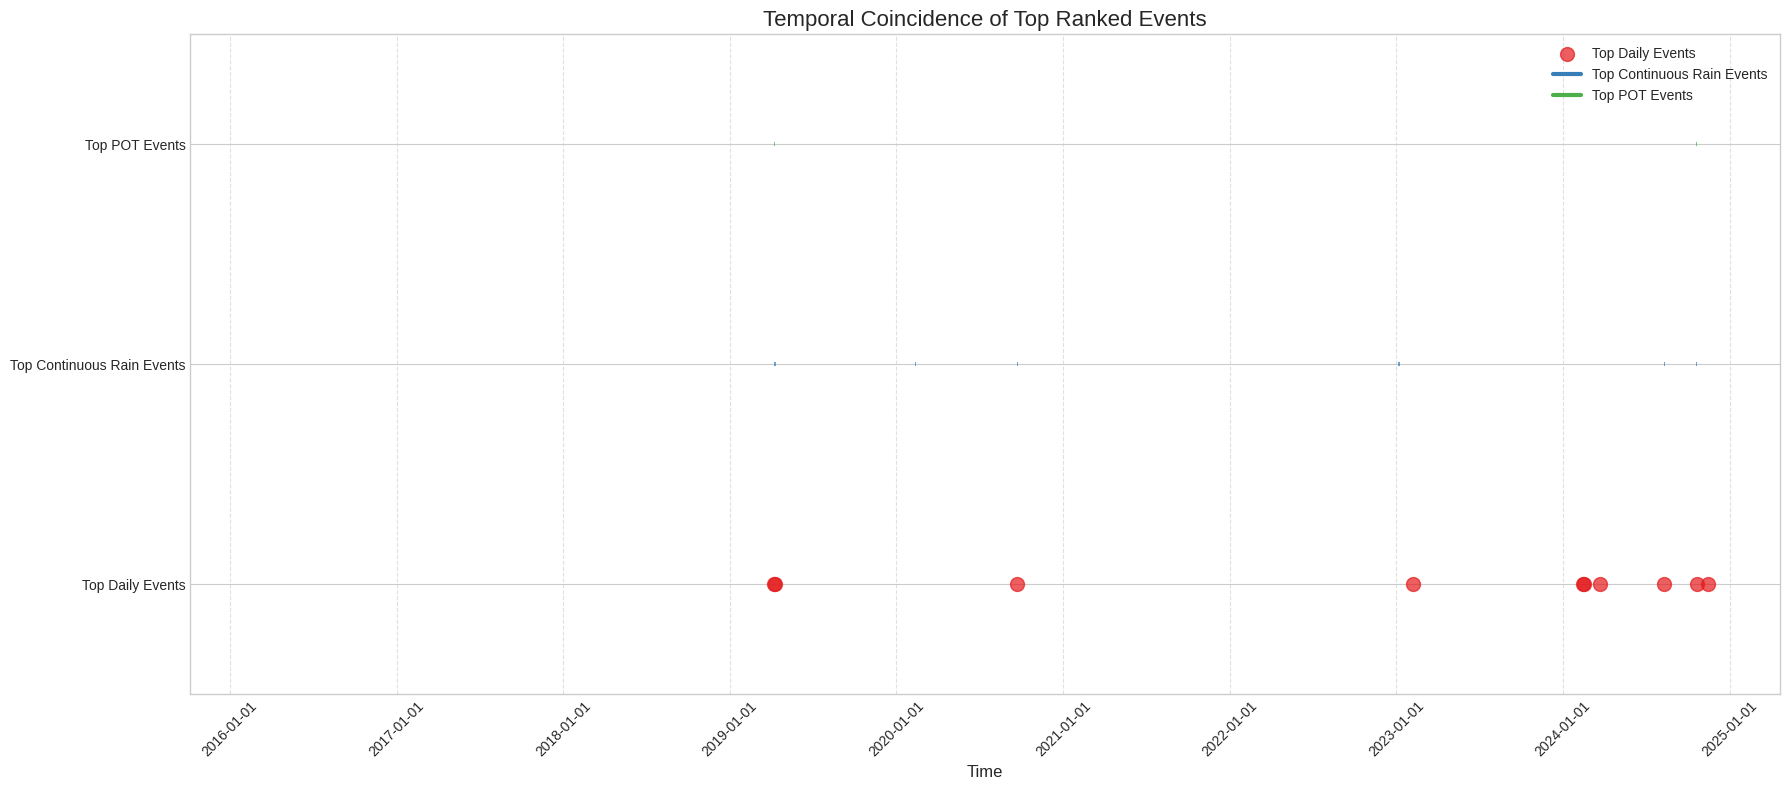

In [ ]:
if 'most_rainy_days' in locals() and not most_rainy_days.empty and \
   'most_intense_events' in locals() and not most_intense_events.empty and \
   'most_significant_pot_events' in locals() and not most_significant_pot_events.empty:

    plt.figure(figsize=(18, 8))
    y_positions = [1, 2, 3]
    event_types_legend = ['Top Daily Events', 'Top Continuous Rain Events', 'Top POT Events']
    colors_legend = [sns.color_palette("Set1")[0], sns.color_palette("Set1")[1], sns.color_palette("Set1")[2]]

    # Plot Top Daily Events (as markers)
    plt.scatter(most_rainy_days['timestamp'], [y_positions[0]]*len(most_rainy_days),
                color=colors_legend[0], marker='o', s=100, label=event_types_legend[0], alpha=0.7, zorder=5)

    # Plot Top Continuous Rain Events (as lines)
    for idx, row in most_intense_events.iterrows():
        plt.plot([row['start_time'], row['end_time']], [y_positions[1], y_positions[1]],
                 color=colors_legend[1], linewidth=3, alpha=0.7, solid_capstyle='butt')
    plt.plot([],[], color=colors_legend[1], linewidth=3, label=event_types_legend[1]) # For legend

    # Plot Top POT Events (as lines)
    for idx, row in most_significant_pot_events.iterrows():
        plt.plot([row['start_time'], row['end_time']], [y_positions[2], y_positions[2]],
                 color=colors_legend[2], linewidth=3, alpha=0.7, solid_capstyle='butt')
    plt.plot([],[], color=colors_legend[2], linewidth=3, label=event_types_legend[2]) # For legend

    plt.yticks(y_positions, event_types_legend)
    plt.title('Temporal Coincidence of Top Ranked Events', fontsize=16)
    plt.xlabel('Time', fontsize=12)
    plt.ylim(0.5, 3.5)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)
    plt.legend(loc='upper right')
    plt.grid(True, axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping temporal coincidence plot: one or more top event DataFrames are missing or empty.")

### 3.7. Discussion on Method Selection for Different Applications

*   **Daily Rainfall Aggregation:** Best for general climatological summaries, long-term trends of wet/dry days, and simple public communication.
*   **Continuous Rainfall Period Identification:** Suited for hydrological modeling, flood forecasting based on event volume/duration, detailed storm system analysis, and understanding typical event structures.
*   **Peak Over Threshold (POT) Event Analysis:** Ideal for flash flood risk, urban drainage design, erosion studies, analysis of extreme short-duration intensities, and high-impact weather warnings.

Often, a combination of methods provides the most comprehensive understanding. The analyses show significant overlaps but also unique insights from each method.

### 3.8. Enhanced Conclusions and Future Directions for Event Analysis

**Key Findings from Comparative Analysis:**
*   Top daily rainfall events are generally well-explained by significant continuous rain events.
*   High-volume continuous events often (but not always) contain POT-level intensities.
*   Days with the highest total rainfall almost invariably include POT events.
*   The three methods are complementary, each highlighting unique aspects of the rainfall regime.

**Refined Conclusions on Rainfall in Rio de Janeiro (based on this analysis):**
*   The rainfall regime is characterized by a mix of frequent, lower-impact events and less frequent, highly significant high-volume/intensity events.
*   The most impactful periods often see alignment across all three metrics (daily total, continuous event volume, POT intensity).

**Future Directions:**
1.  **Parameter Sensitivity Analysis:** Systematically vary event definition parameters.
2.  **Correlation with Impacts:** Correlate identified events with `ocorrencias_gdf` (flood reports, etc.) to validate predictive power.
3.  **Spatial Variability:** Extend analysis to individual rain gauges before areal averaging.
4.  **Seasonality and Trend Analysis:** Investigate seasonality and long-term trends of different event types.
5.  **Advanced Event Definitions:** Explore multivariate event definitions or established hydrological/meteorological storm typing methods (e.g., based on Intensity-Duration-Frequency, inter-event time definitions).

This detailed framework provides a solid foundation for more advanced hydro-meteorological studies.

---

## Part 4: Focused Visualization of Top Rain Events with Hourly Maps

This section visualizes the spatio-temporal evolution of rainfall and associated flood occurrences for the top rain events.

### 4.1. Selection of Method for Defining Top Rain Events for Visualization

The **Continuous Rainfall Period Identification** method (resulting in `rain_events_df` and its derivative `most_intense_events`) is chosen for selecting comprehensive rain events. This method captures the full lifecycle of a rain period, providing a coherent event profile (start, end, duration, volume, peak intensity) suitable for detailed spatio-temporal visualization.

### 4.2. Generating 3-Hourly Rainfall Maps for Top 10 Continuous Rain Events

For each of the top 10 continuous rain events (from `most_intense_events`), we generate a series of maps. Each map represents a 3-hour interval, typically covering a 24-hour period centered around the event's activity. The maps display:
*   Thiessen polygons colored by 3-hour accumulated rainfall at their associated stations.
*   Flood occurrences reported within that specific 3-hour window.
*   A basemap and the city boundary for spatial context.

/home/luisresende/work/envs/jupyter/lib/python3.10/site-packages/cartopy/io/img_tiles.py:113: UserWarning: Cartopy created the following directory to cache GoogleWTS tiles: /tmp/cartopy_cache_dir/ArcGISWorldLightGray
  warnings.warn(



Generating 3-Hourly Maps for Continuous Event ID: 1268
   Event Start: 2019-04-08 15:15:00, Event End: 2019-04-11 05:30:00
<urlopen error [Errno 113] No route to host>
<urlopen error [Errno 113] No route to host>
<urlopen error [Errno 113] No route to host>
<urlopen error [Errno 113] No route to host>
<urlopen error [Errno 113] No route to host>
<urlopen error [Errno 113] No route to host>
<urlopen error [Errno 113] No route to host>
<urlopen error [Errno 113] No route to host>
<urlopen error [Errno 113] No route to host>
<urlopen error [Errno 113] No route to host>
<urlopen error [Errno 113] No route to host>
<urlopen error [Errno 113] No route to host>
<urlopen error [Errno 113] No route to host>
<urlopen error [Errno 113] No route to host>
<urlopen error [Errno 113] No route to host>
<urlopen error [Errno 113] No route to host>
<urlopen error [Errno 113] No route to host>
<urlopen error [Errno 113] No route to host>
<urlopen error [Errno 113] No route to host>
<urlopen error [Errno

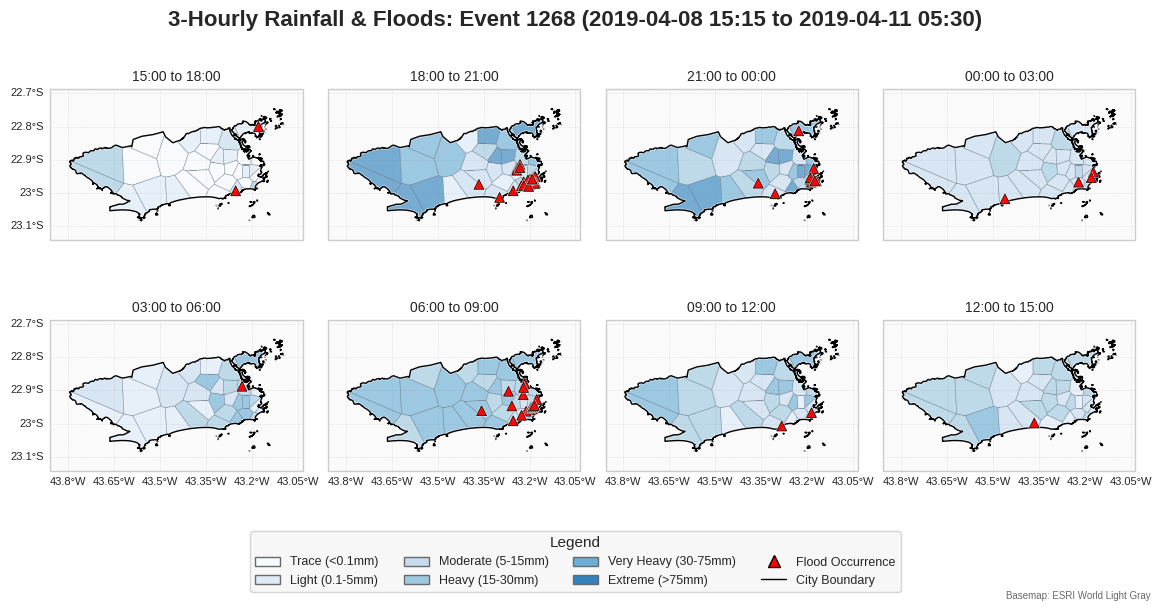


Generating 3-Hourly Maps for Continuous Event ID: 2802
   Event Start: 2024-03-22 07:45:00, Event End: 2024-03-23 03:45:00


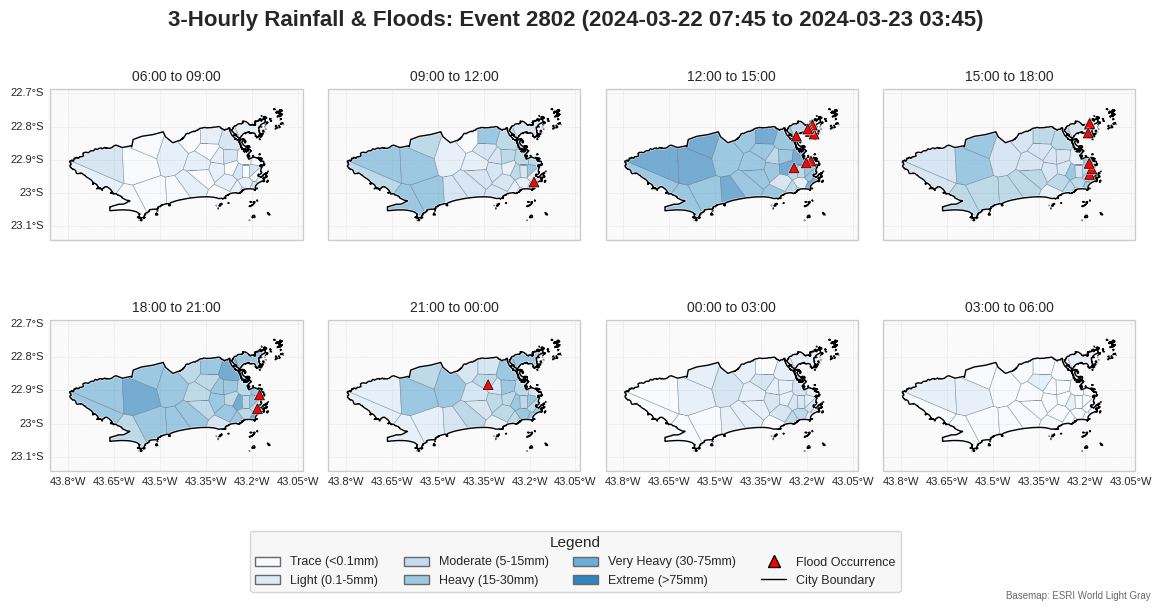


Generating 3-Hourly Maps for Continuous Event ID: 2906
   Event Start: 2024-10-19 14:45:00, Event End: 2024-10-20 21:30:00


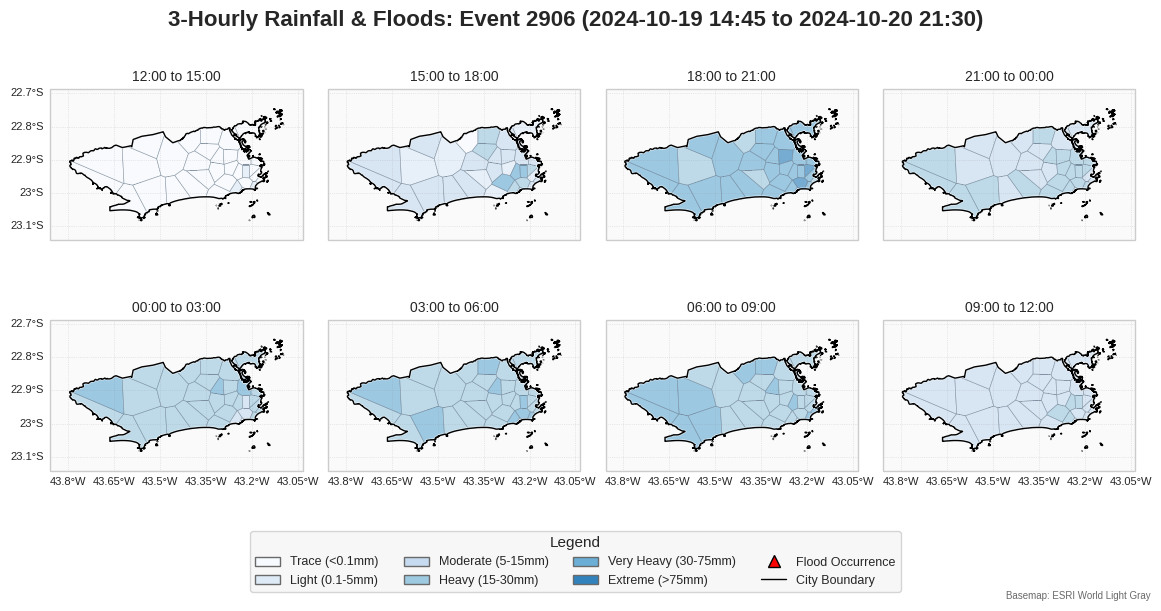


Generating 3-Hourly Maps for Continuous Event ID: 2887
   Event Start: 2024-08-09 21:30:00, Event End: 2024-08-10 18:30:00


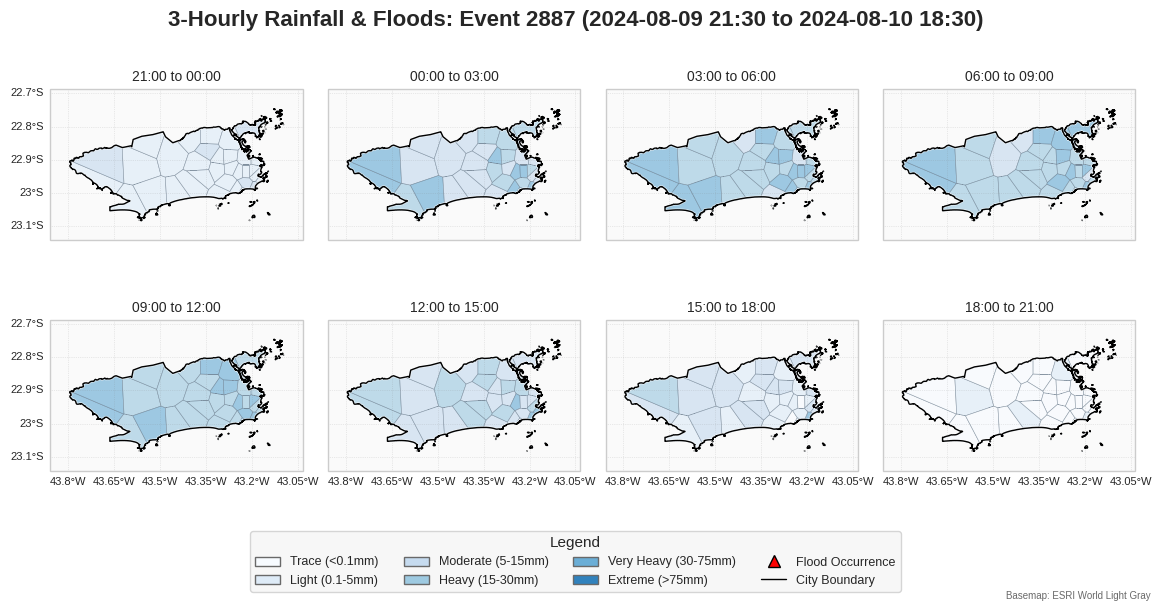


Generating 3-Hourly Maps for Continuous Event ID: 1639
   Event Start: 2020-09-21 18:45:00, Event End: 2020-09-23 04:30:00


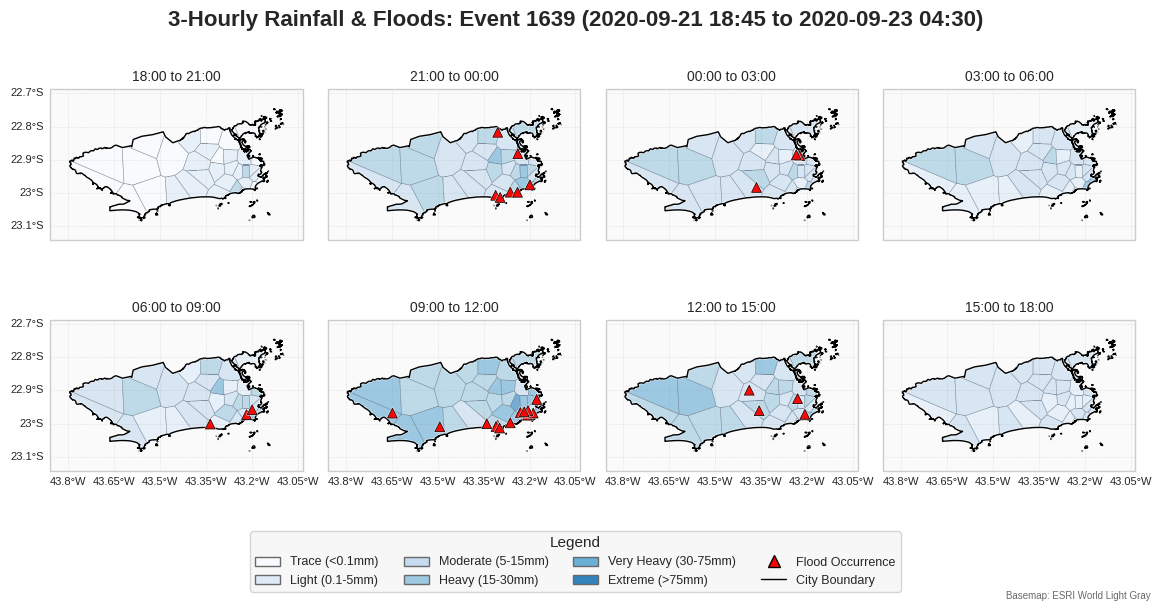


Generating 3-Hourly Maps for Continuous Event ID: 2754
   Event Start: 2024-02-17 10:45:00, Event End: 2024-02-17 11:45:00


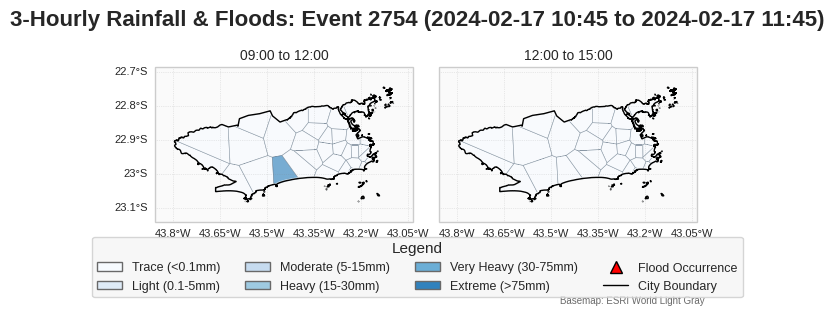


Generating 3-Hourly Maps for Continuous Event ID: 1496
   Event Start: 2020-02-10 14:30:00, Event End: 2020-02-13 07:15:00


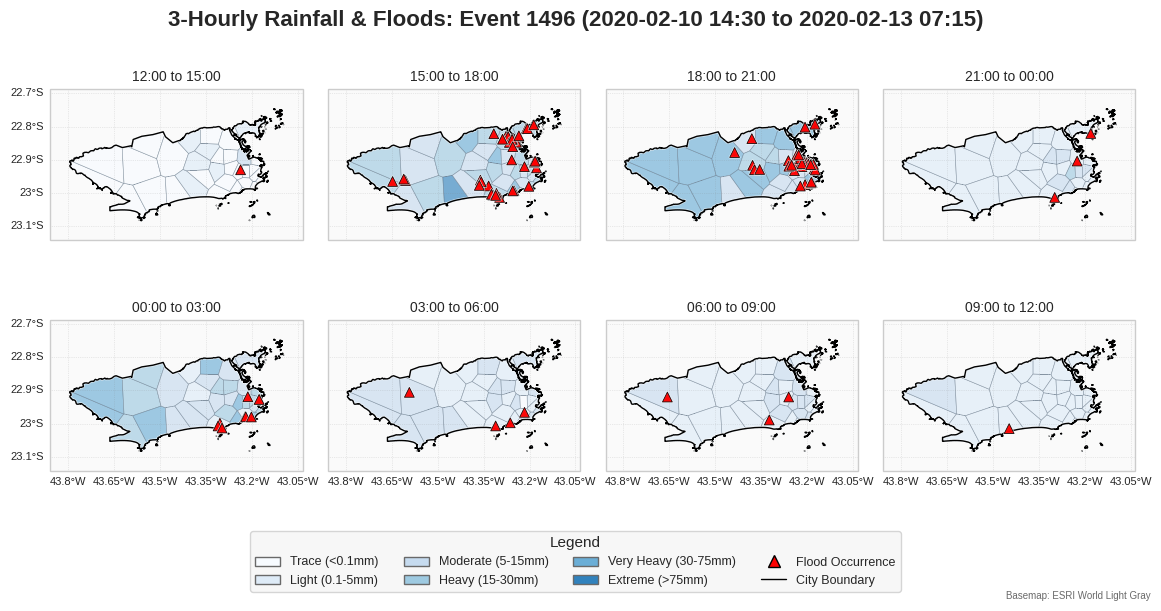


Generating 3-Hourly Maps for Continuous Event ID: 1520
   Event Start: 2020-02-29 19:45:00, Event End: 2020-03-02 00:45:00


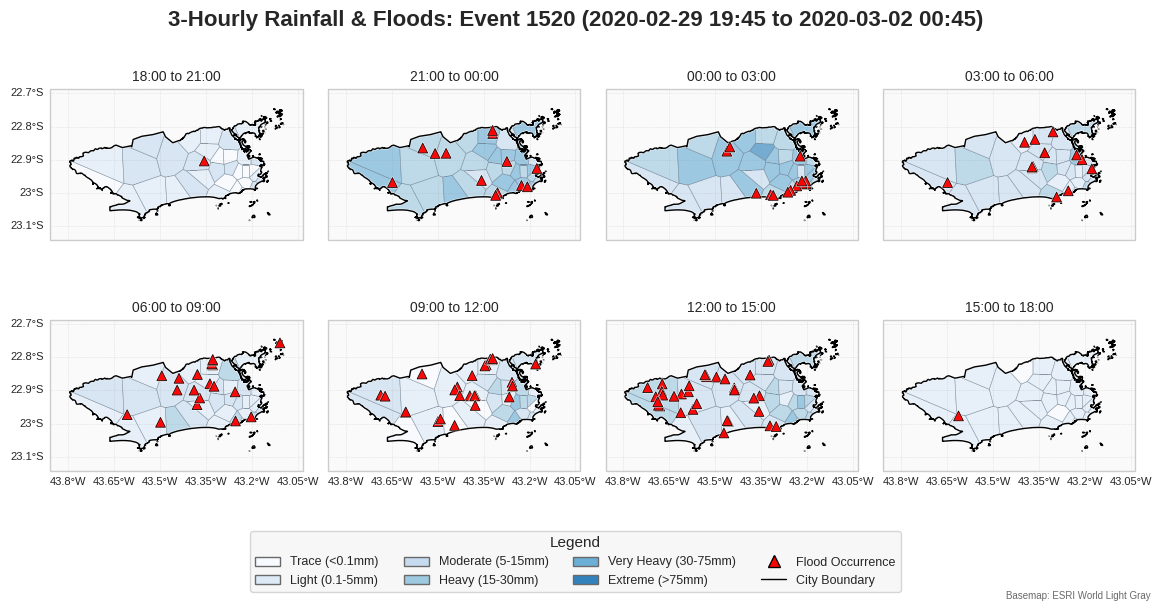


Generating 3-Hourly Maps for Continuous Event ID: 2432
   Event Start: 2023-01-05 06:00:00, Event End: 2023-01-08 01:45:00


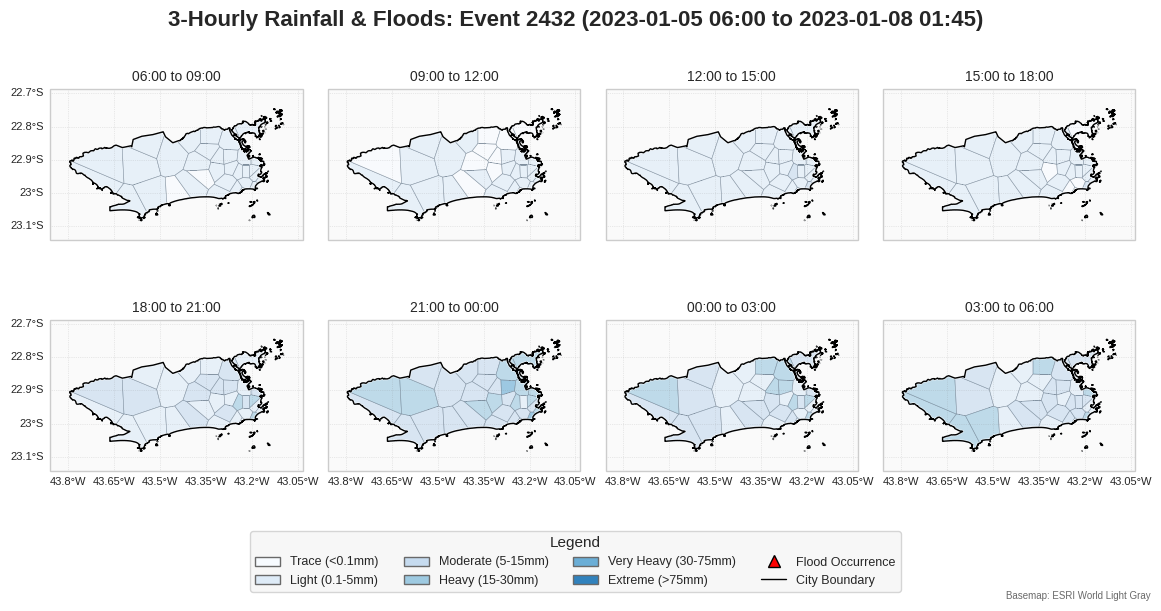


Generating 3-Hourly Maps for Continuous Event ID: 2750
   Event Start: 2024-02-15 08:00:00, Event End: 2024-02-16 01:15:00


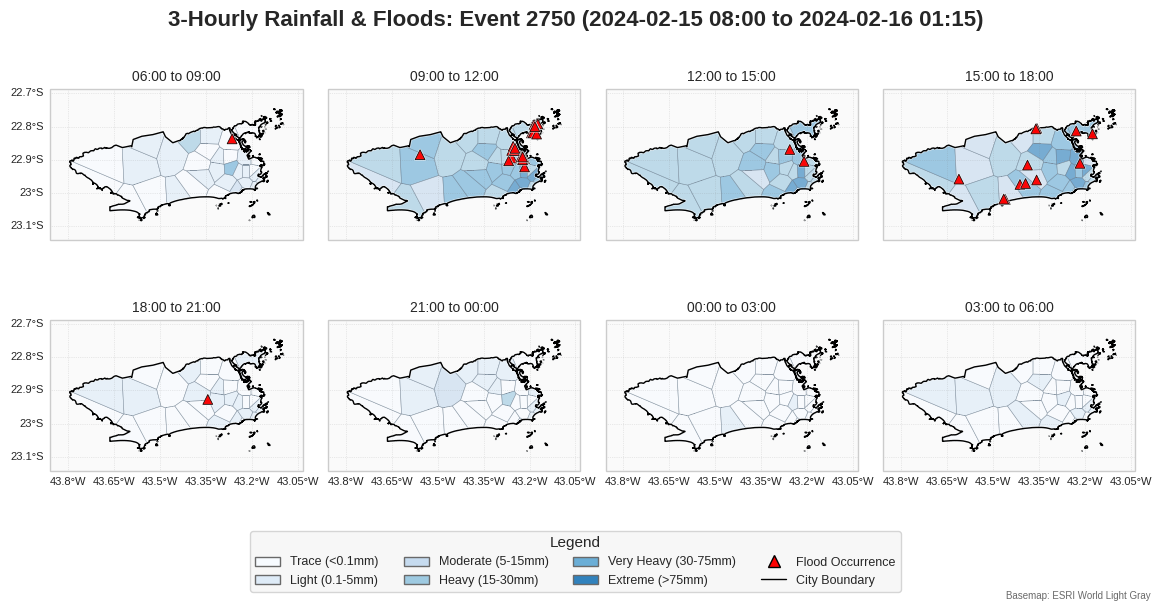


--- End of Part 4: Focused Visualization ---


In [ ]:
# Ensure all necessary variables (most_intense_events, alertario, thiessen_polygons_gdf, city_boundary_gdf, ocorrencias_gdf)
# are loaded and processed from previous parts.
# Cartopy and other plotting libraries should also be imported.

if 'most_intense_events' not in locals() or most_intense_events.empty:
    print("Top continuous rain events ('most_intense_events') not found. Skipping map generation.")
elif ccrs is None: # Check if Cartopy was imported successfully
    print("Cartopy library not found. Skipping map generation.")
else:
    # --- ArcGIS Tiler Setup (if not already globally defined) ---
    class ArcGISWorldLightGray(cimgt.GoogleTiles):
        def _image_url(self, tile):
            x, y, z = tile
            # Correct URL for the World_Light_Gray_Base service
            return f"https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}"

    tiler = ArcGISWorldLightGray(cache=True) # Enable caching
    map_projection_crs = tiler.crs # Use the CRS of the tile service
    data_geographic_crs = ccrs.PlateCarree() # Standard geographic CRS for lat/lon gridlines

    # --- Rainfall Colors and Binning (for 3-hourly accumulation) ---
    # Adjust bins if 3-hourly totals are different from 1-hourly in original notebook
    rainfall_bins_3hr = [0, 0.1, 5, 15, 30, 75, np.inf] # Example bins for 3-hr accumulation
    rainfall_labels_3hr = [
        "Trace (<0.1mm)", "Light (0.1-5mm)", "Moderate (5-15mm)",
        "Heavy (15-30mm)", "Very Heavy (30-75mm)", "Extreme (>75mm)"
    ]
    # Ensure colors match number of categories (len(bins)-1)
    rainfall_colors_3hr = ['#f7fbff', '#deebf7', '#c6dbef', '#9ecae1', '#6baed6', '#3182bd', '#08519c'][:len(rainfall_bins_3hr)-1]
    custom_cmap_3hr = ListedColormap(rainfall_colors_3hr)
    norm_3hr = BoundaryNorm(rainfall_bins_3hr, custom_cmap_3hr.N)

    # --- Map Extent (projected city boundary to map CRS) ---
    city_boundary_map_proj = city_boundary_gdf.to_crs(map_projection_crs) # Ensure city_boundary_gdf is in CRS_PROJECTED first
    xmin_map, ymin_map, xmax_map, ymax_map = city_boundary_map_proj.total_bounds
    padding_map = 7000 # meters, adjust as needed
    map_extent_viz = [xmin_map - padding_map, xmax_map + padding_map,
                      ymin_map - padding_map, ymax_map + padding_map]
    TARGET_TILE_RESOLUTION_VIZ = 11 # Zoom level for tiles

    # --- Ensure Data is in Correct CRS for Plotting ---
    # Thiessen polygons should be in CRS_PROJECTED from Part 1
    if thiessen_polygons_gdf.crs != CRS_PROJECTED:
        thiessen_polygons_gdf = thiessen_polygons_gdf.to_crs(CRS_PROJECTED)
    # Ocorrencias should be in CRS_PROJECTED from Part 1
    if not ocorrencias_gdf.empty and ocorrencias_gdf.crs != CRS_PROJECTED:
        ocorrencias_gdf = ocorrencias_gdf.to_crs(CRS_PROJECTED)


    # --- Loop Through Top Events and Generate Maps ---
    for index, event_row in most_intense_events.iterrows():
        event_id = event_row['event_id']
        event_start_time = event_row['start_time']
        event_end_time = event_row['end_time']
        print(f"\nGenerating 3-Hourly Maps for Continuous Event ID: {event_id}")
        print(f"   Event Start: {event_start_time}, Event End: {event_end_time}")

        # Define 3-hour timestamps for visualization (e.g., 8 intervals covering 24 hours around event peak or start)
        # The original function `generate_3h_timestamps` seemed to pick a fixed time of day.
        # Let's make it more dynamic around the event's core activity.
        # For simplicity, we'll take 8 three-hour slots starting from the event_start_time,
        # or centered if the event is short.
        num_map_intervals = 8
        vis_start_points = pd.date_range(start=event_start_time.floor('3h'), periods=num_map_intervals, freq='3h')
        
        # If event is very short, ensure we don't go too far past its end
        vis_start_points = vis_start_points[vis_start_points < str(event_end_time + pd.Timedelta(hours=3))]
        if len(vis_start_points) == 0 and event_start_time < str(event_end_time) : # handle very short events
            vis_start_points = pd.DatetimeIndex([event_start_time.floor('3h')])
        
        if len(vis_start_points) == 0:
            print(f"   Skipping maps for event {event_id} as its duration is too short for 3H intervals or vis_start_points is empty.")
            continue

        # Resample station rainfall to 3-hourly for this event's visualization window
        alertario_event_window = alertario[
            (alertario['timestamp'] >= str(vis_start_points.min())) &
            (alertario['timestamp'] < str(vis_start_points.max() + pd.Timedelta(hours=3))) # Cover full last interval
        ]
        
        three_hourly_station_rain_event = pd.DataFrame()
        if not alertario_event_window.empty:
            resampled_list_3hr = []
            for station_id, group in alertario_event_window.groupby('id_estacao'):
                # Ensure 'timestamp' is datetime and set as index for resampling
                group_ts_indexed = group.copy()
                if not pd.api.types.is_datetime64_any_dtype(group_ts_indexed['timestamp']):
                    group_ts_indexed['timestamp'] = pd.to_datetime(group_ts_indexed['timestamp'])
                group_ts_indexed = group_ts_indexed.set_index('timestamp')
                
                resampled_3hr = group_ts_indexed['acumulado_chuva_15_min'].resample('3h').sum()
                if not resampled_3hr.empty:
                    df_3hr = resampled_3hr.reset_index()
                    df_3hr['id_estacao'] = station_id
                    resampled_list_3hr.append(df_3hr)
            if resampled_list_3hr:
                three_hourly_station_rain_event = pd.concat(resampled_list_3hr)
                three_hourly_station_rain_event.rename(columns={'acumulado_chuva_15_min': 'rain_3hr_mm'}, inplace=True)
        
        # Plotting: Dynamic grid based on number of visualization start points
        ncols_grid = min(4, len(vis_start_points)) # Max 4 columns
        nrows_grid = (len(vis_start_points) + ncols_grid - 1) // ncols_grid # Calculate rows needed
        
        fig = plt.figure(figsize=(3.5 * ncols_grid, 3 * nrows_grid)) # Adjusted figsize
        gs_main = gridspec.GridSpec(nrows_grid, ncols_grid, figure=fig, hspace=0.3, wspace=0.1) # Added wspace

        for i, map_interval_start_time in enumerate(vis_start_points):
            row_idx, col_idx = divmod(i, ncols_grid)
            ax = fig.add_subplot(gs_main[row_idx, col_idx], projection=map_projection_crs)
            map_interval_end_time = map_interval_start_time + pd.Timedelta(hours=3)

            ax.set_extent(map_extent_viz, crs=map_projection_crs)
            ax.add_image(tiler, TARGET_TILE_RESOLUTION_VIZ, interpolation='bilinear', zorder=0)

            current_interval_station_data = pd.DataFrame()
            if not three_hourly_station_rain_event.empty:
                current_interval_station_data = three_hourly_station_rain_event[
                    three_hourly_station_rain_event['timestamp'] == map_interval_start_time
                ]

            thiessen_viz_gdf = thiessen_polygons_gdf.merge(
                current_interval_station_data[['id_estacao', 'rain_3hr_mm']],
                on='id_estacao', how='left'
            ).fillna({'rain_3hr_mm': 0})
            thiessen_viz_gdf_map_proj = thiessen_viz_gdf.to_crs(map_projection_crs)

            # Plot Thiessen polygons
            for _, poly_row_viz in thiessen_viz_gdf_map_proj.iterrows():
                rain_val = poly_row_viz['rain_3hr_mm']
                color_idx = norm_3hr(rain_val) # Apply normalization
                color = custom_cmap_3hr(color_idx) # Get color from colormap
                ax.add_geometries([poly_row_viz.geometry], crs=map_projection_crs,
                                  facecolor=color, edgecolor='slategray',
                                  linewidth=0.4, alpha=0.65, zorder=2)

            # Plot city boundary
            ax.add_geometries(city_boundary_map_proj.geometry, crs=map_projection_crs,
                              facecolor='none', edgecolor='black', linewidth=1.0, zorder=4,
                              path_effects=[PathEffects.withStroke(linewidth=2.0, foreground='white', alpha=0.6)])
            
            # Plot flood occurrences
            active_ocorrencias_map = pd.DataFrame()
            if not ocorrencias_gdf.empty:
                active_ocorrencias_map = ocorrencias_gdf[ # Use original ocorrencias_gdf (projected)
                    (ocorrencias_gdf['data_inicio'] >= str(map_interval_start_time)) &
                    (ocorrencias_gdf['data_inicio'] < str(map_interval_end_time))
                ]
            if not active_ocorrencias_map.empty:
                ocorr_proj_interval = active_ocorrencias_map.to_crs(map_projection_crs)
                ax.scatter(ocorr_proj_interval.geometry.x, ocorr_proj_interval.geometry.y,
                           transform=map_projection_crs, marker='^', color='red', s=50, alpha=0.9,
                           edgecolor='black', linewidth=0.6, zorder=5,
                           path_effects=[PathEffects.withStroke(linewidth=1.5, foreground='white', alpha=0.7)])

            ax.set_title(f"{map_interval_start_time:%H:%M} to {map_interval_end_time:%H:%M}", fontsize=10)
            
            # Gridlines (optional, can make plot busy)
            gl = ax.gridlines(crs=data_geographic_crs, draw_labels=False, # Labels off for subplots usually
                              linewidth=0.5, color='gray', alpha=0.3, linestyle=':')
            if col_idx == 0: gl.left_labels = True # Labels on left-most plots
            if row_idx == nrows_grid -1 : gl.bottom_labels = True # Labels on bottom-most plots
            gl.xlabel_style = {'size': 8}; gl.ylabel_style = {'size': 8}


        # --- Custom Legend for the Figure ---
        legend_handles = [
            mpatches.Patch(facecolor=color, edgecolor='dimgray', label=label)
            for color, label in zip(rainfall_colors_3hr, rainfall_labels_3hr)
        ]
        if not ocorrencias_gdf.empty:
             legend_handles.append(plt.Line2D([0], [0], marker='^', color='none', label='Flood Occurrence',
                                         markerfacecolor='red', markeredgecolor='black', markersize=8))
        legend_handles.append(plt.Line2D([0], [0], color='black', lw=1.0, label='City Boundary'))

        fig.legend(handles=legend_handles, loc='lower center', ncol=min(4, len(legend_handles)),
                   bbox_to_anchor=(0.5, 0.01), fontsize=9, title="Legend",
                   title_fontsize=11, frameon=True, facecolor='whitesmoke', framealpha=0.8)

        fig.text(0.911, 0.005, f"Basemap: ESRI World Light Gray",
                 ha='right', va='bottom', fontsize=7, color='dimgray')

        fig.suptitle(f"3-Hourly Rainfall & Floods: Event {event_id} ({event_start_time:%Y-%m-%d %H:%M} to {event_end_time:%Y-%m-%d %H:%M})",
                     fontsize=16, fontweight='bold', y=0.99)
        
        plt.subplots_adjust(bottom=0.2) # Adjust bottom to make space for legend
        plt.show()

print("\n--- End of Part 4: Focused Visualization ---")

---

**End of Notebook**
